<div style="text-align:center; background-color:#fff6e4; padding:20px; border:5px solid #f5ecda; border-radius:8px;">
    <div style="font-size:36px; font-weight:bold; color:#4A4A4A;">
        Medical Cost Prediction
    </div>
    <div style="font-size:24px; font-weight:bold; color:#4A4A4A;">
        Part 2: Modeling
    </div>
    <div style="font-size:14px; font-weight:normal; color:#666; margin-top:16px;">
        Author: Jens Bender <br> 
        Created: March 2026<br>
        Last updated: May 2026
    </div>
</div>

<div style="background-color:#2c699d; color:white; padding:15px; border-radius:6px;">
    <h1 style="margin:0px">Setup</h1>
</div>

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    <strong>Notebook Settings</strong>
</div>

In [ ]:
# Automatically reload local modules before each cell run (prevents having to restart kernel after changes)
%load_ext autoreload
%autoreload 2

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    <strong>Imports</strong>
</div>

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.compose import TransformedTargetRegressor  # to log-transform target
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Model selection
from sklearn.model_selection import ParameterSampler

# Model evaluation
from sklearn.metrics import (
    mean_absolute_error, 
    mean_pinball_loss,
    r2_score
)
import time  # to measure training time

# Local imports
from src.modeling import (
    get_baseline_models,
    train_and_evaluate,
    weighted_median_absolute_error,
    save_model,
    load_model,
    save_metrics,
    load_metrics,
    get_core_model_params
)
from src.stats import (
    weighted_quantile,
    weighted_std,
    create_stratification_bins
)
from src.params import (
    EN_PARAM_DISTRIBUTIONS,
    RF_PARAM_DISTRIBUTIONS, 
    XGB_PARAM_DISTRIBUTIONS 
)
from src.constants import (
    ID_COLUMN,
    WEIGHT_COLUMN,
    TARGET_COLUMN,
    RANDOM_STATE
)
from src.display import (
    DISPLAY_LABELS, 
    METRIC_LABELS,
    MODEL_DISPLAY_LABELS,
    CATEGORY_LABELS_EDA,
    POP_COLOR,
    SAMPLE_COLOR,
    TYPICAL_RANGE_COLOR,
    SAFETY_CUSHION_COLOR,
    add_table_caption
)

<div style="background-color:#2c699d; color:white; padding:15px; border-radius:6px;">
    <h1 style="margin:0px">Data Loading</h1>
</div>
<div style="background-color:#fff6e4; padding:15px; border:3px solid #f5ecda; border-radius:6px;">
    📌 Load the preprocessed data from the <code>.parquet</code> files into Pandas DataFrames.
</div>

In [ ]:
df_train_preprocessed = pd.read_parquet("../data/training_data_preprocessed.parquet")
df_val_preprocessed = pd.read_parquet("../data/validation_data_preprocessed.parquet")
df_test_preprocessed = pd.read_parquet("../data/test_data_preprocessed.parquet")

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> 
    📌 Inspect the data.
</div>

In [ ]:
def inspect_df(df):
    """
    Inspect a DataFrame and return its shape and data integrity status.

    Args:
        df (pd.DataFrame): The DataFrame to be validated.

    Returns:
        list: A list containing:
            - tuple: Shape of the DataFrame (rows, columns).
            - str: Status icon for numerical-only columns (✅ if all numerical, ❌ otherwise).
            - str: Status icon for missing values (✅ if none, ❌ otherwise).
            - str: Status icon for infinite values (✅ if none, ❌ otherwise).
            - str: Status icon for constant columns (✅ if none, ❌ otherwise).
            - str: Status icon for unique index/ID (✅ if unique, ❌ otherwise).
            - str: Status icon for target variable presence (✅ if TARGET_COLUMN exists, ❌ otherwise).
            - str: Status icon for weight variable presence (✅ if WEIGHT_COLUMN exists, ❌ otherwise).
    """
    shape = df.shape
    no_missings = "✅" if not df.isna().any().any() else "❌"
    all_numerical = "✅" if df.select_dtypes(exclude=[np.number]).empty else "❌"
    no_infinites = "✅" if not np.isinf(df.select_dtypes(include=[np.number])).any().any() else "❌"
    no_constants = "✅" if (df.nunique(dropna=False) > 1).all() else "❌"
    unique_id = "✅" if (df.index.is_unique and df.index.name == ID_COLUMN) else "❌"
    target_present = "✅" if TARGET_COLUMN in df.columns else "❌"
    weights_present = "✅" if WEIGHT_COLUMN in df.columns else "❌"

    return [
        shape,
        all_numerical,
        no_missings,
        no_infinites,
        no_constants,
        unique_id,
        target_present,
        weights_present,
    ]

data_inspection = pd.DataFrame(
    {
        "Training": inspect_df(df_train_preprocessed),
        "Validation": inspect_df(df_val_preprocessed),
        "Test": inspect_df(df_test_preprocessed),
    },
    index=[
        "Shape",
        "All Numerical",
        "No Missings",
        "No Infinites",
        "No Constants",
        "Unique ID",
        "Target Present",
        "Weights Present",
    ],
)
display(data_inspection.style.pipe(add_table_caption, "Data Inspection"))

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> 
    📌 Split the preprocessed data into X features, y target variable, and sample weights (w).
</div>

In [ ]:
X_train_preprocessed = df_train_preprocessed.drop([TARGET_COLUMN, WEIGHT_COLUMN], axis=1)
y_train = df_train_preprocessed[TARGET_COLUMN]
w_train = df_train_preprocessed[WEIGHT_COLUMN]

X_val_preprocessed = df_val_preprocessed.drop([TARGET_COLUMN, WEIGHT_COLUMN], axis=1)
y_val = df_val_preprocessed[TARGET_COLUMN]
w_val = df_val_preprocessed[WEIGHT_COLUMN]

X_test_preprocessed = df_test_preprocessed.drop([TARGET_COLUMN, WEIGHT_COLUMN], axis=1)
y_test = df_test_preprocessed[TARGET_COLUMN]
w_test = df_test_preprocessed[WEIGHT_COLUMN]

# Delete redundant DataFrames to free up memory
del df_train_preprocessed, df_val_preprocessed, df_test_preprocessed

<div style="background-color:#2c699d; color:white; padding:15px; border-radius:6px;">
    <h1 style="margin:0px">Baseline Models</h1>
</div> 

<div style="background-color:#3d7ab3; color:white; padding:12px; border-radius:6px;">
    <h2 style="margin:0px">Training</h2>
</div> 

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    ℹ️ Train 6 baseline models with distribution-aware baseline hyperparameters.  
    <ul>
        <li>Linear Regression (lr)</li>
        <li>Elastic Net Regression (en)</li>
        <li>Decision Tree Regressor (tree)</li>
        <li>Random Forest Regressor (rf)</li>
        <li>XGBoost Regressor (xgb)</li>
        <li>Support Vector Regressor (svr)</li>
    </ul>
    Training Setup:
    <ul>
        <li>Train on preprocessed data (standardized, imputed, feature engineered, scaled, and encoded).</li>
        <li>Train on all candidate features (27 raw, 40 preprocessed).</li>
        <li>Use sample weights for population representativeness. Normalize weights (mean=1.0) to maintain relative importance while ensuring numerical stability during training (especially for svr).</li>
        <li>Apply log-transformation of target variable for all baseline models using <code>TransformedTargetRegressor</code>. Use <code>log1p</code> instead of <code>log</code> to handle zeros in target (<code>log(0)</code> is undefined).</li>
        <li>Implement polynomial features for elastic net regression using second-degree <code>PolynomialFeatures</code> with a small <code>Pipeline</code>.</li>
        <li>For each model, store the following artifacts: the fitted model as a <code>.joblib</code> file, evaluation metrics as a <code>.json</code> file, model parameters as a <code>.json</code> file, predictions as a <code>.joblib</code> file.</li>
    </ul>  
    For more details, see <a href="../src/modeling.py">src/modeling.py</a>.
    <br><br>
    Note: This notebook is used for prototyping, the production training run was executed via the reproducible script <code><a href="../scripts/train_baseline.py">scripts/train_baseline.py</a></code>.
</div>

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    📌 Train and evaluate each baseline model and store model results.
</div> 

In [ ]:
# Build baseline models (using helper function from "src/modeling.py")
baseline_models = get_baseline_models()

# Train and evaluate linear regression model (example usage of train_and_evaluate) 
# lr_results = train_and_evaluate(baseline_models["Linear Regression"], X_train_preprocessed, y_train, X_val_preprocessed, y_val, w_train, w_val)
# lr_metrics = pd.DataFrame([lr_results])[["mdae", "mae", "r2", "training_time"]]
# display(lr_metrics.rename(columns=METRIC_LABELS).style.pipe(add_table_caption, "Linear Regression: Metrics").format("{:.2f}").hide()) 


def train_and_evaluate_all_models(models, X_train, y_train, X_val, y_val, w_train=None, w_val=None):
    """
    Train and evaluate multiple models and consolidate their results.

    Args:
        models (dict): A dictionary mapping model names (str) to model objects (estimators).
        X_train (pd.DataFrame): Preprocessed training features.
        y_train (pd.Series): Target variable for training data.
        X_val (pd.DataFrame): Preprocessed validation features.
        y_val (pd.Series): Target variable for validation data.
        w_train (pd.Series, optional): Sample weights for training data. Defaults to None.
        w_val (pd.Series, optional): Sample weights for validation data. Defaults to None.

    Returns:
        dict: A dictionary of evaluation results for each model, where keys are model names and
              values are the dictionaries returned by the `train_and_evaluate` function.
    """
    print("Training and evaluating baseline models...")    
    results = {}
    for model_name, model in models.items():
        print(f"Training {model_name}...")
        result = train_and_evaluate(model, X_train, y_train, X_val, y_val, w_train, w_val)
        results[model_name] = result
        print(f"  {model_name} trained in {result['training_time']:.2f} sec (MdAE: {result['val_mdae']:.2f})")        
    return results


def persist_all_models(model_results):
    """
    Save baseline model results in various files:
      1.  Saves each fitted model object individually as a .joblib file.
      2.  Aggregates all performance metrics into a single JSON file.
      3.  Saves predictions of all models on the validation data into a single .joblib file.
    Args:
        model_results (dict): A nested dictionary mapping model names to results 
            dictionaries (containing 'fitted_model', training and validation metrics 
            (e.g. 'val_mdae', 'train_mdae'), and 'y_val_pred').
    """
    print("Persisting baseline models...")
    all_metrics = {}
    all_predictions = {}
    for model_name, result in model_results.items():        
        # Save fitted model as .joblib file 
        model_id = model_name.lower().replace(" ", "_")
        model_path = f"models/{model_id}_baseline.joblib"
        save_model(result["fitted_model"], model_path, verbose=False)
        print(f"  Saved fitted {model_name} model to '{model_path}'")
        
        # Collect evaluation metrics of all models in single dictionary
        all_metrics[model_name] = {
            "val_mdae": result["val_mdae"],
            "val_mae": result["val_mae"],
            "val_r2": result["val_r2"],
            "train_mdae": result["train_mdae"],
            "train_mae": result["train_mae"],
            "train_r2": result["train_r2"]
        }
        
        # Collect predicted values of all models in single dictionary
        all_predictions[model_name] = result["y_val_pred"]

    # Save evaluation metrics as JSON 
    save_metrics(all_metrics, "models/baseline_metrics.json", verbose=False)
    print(f"  Saved model evaluation metrics to 'models/baseline_metrics.json'")
    
    # Save predictions as .joblib file 
    save_model(all_predictions, "models/baseline_predictions.joblib", verbose=False)
    print(f"  Saved predicted values of all baseline models to 'models/baseline_predictions.joblib'")


# Train and evaluate baseline models
# baseline_results = train_and_evaluate_all_models(baseline_models, X_train_preprocessed, y_train, X_val_preprocessed, y_val, w_train, w_val)

# Save baseline model results
# persist_all_models(baseline_results)

<div style="background-color:#3d7ab3; color:white; padding:12px; border-radius:6px;">
    <h2 style="margin:0px">Evaluation</h2>
</div> 

<div style="background-color:#4e8ac8; color:white; padding:10px; border-radius:6px;">
    <h3 style="margin:0px">Metrics</h3>
</div>

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    🎯 Evaluate model performance on the validation dataset.  
    <ul>
        <li>Primary Metric:
            <ul>
                <li>Median Absolute Error (Target: MdAE < $500)</li>
            </ul>
        </li>
        <li>Secondary Metrics:
            <ul>
                <li>Mean Absolute Error (MAE)</li>
                <li>Coefficient of Determination (R²)</li>
            </ul>     
        </li>
        <li>Additional Diagnostics:
            <ul>
                <li>Metrics Comparison Tables</li>
                <li>Overfitting Analysis</li>
            </ul>
        </li>
    </ul>
</div>

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    <strong>Metric Comparison Table</strong><br>
    📌 Compare evaluation metrics of all baseline models on the validation data.
</div> 

In [ ]:
# Load baseline model metrics from JSON files 
baseline_models_to_evaluate = ["median", "lr", "en", "tree", "rf", "xgb", "svm"]
baseline_metrics = {}
for model in baseline_models_to_evaluate:
    metrics = load_metrics(f"../models/{model}_baseline_metrics.json")
    baseline_metrics.update(metrics)

# Display metric comparison table
display(
    pd.DataFrame(baseline_metrics).T[["val_mdae", "val_mae", "val_r2"]]
    .rename(columns=lambda x: METRIC_LABELS.get(x, x).replace(" (Val)", ""))
    .rename(index=lambda x: MODEL_DISPLAY_LABELS.get(x, x).replace(" (Baseline)", ""))
    .style
    .pipe(add_table_caption, "Baseline Model Metrics (Validation Data)")
    .format("{:.2f}")
)

<div style="background-color:#f7fff8; padding:15px; border:3px solid #e0f0e0; border-radius:6px;">
    💡 <strong>Note on Negative $r^2$ Scores</strong>
    <br>
    Indicates the model performs worse than always predicting the mean. This is common in medical cost prediction for several reasons:
    <ul>
        <li><strong>Sensitivity to Outliers</strong>: $R^2$ uses squared errors. Since medical costs are extremely heavy-tailed, even a few large mispredictions on high-cost individuals can cause the squared error to explode.</li>
        <li><strong>Log-Transformation</strong>: While log-transforming handles skewness, small errors in "log-space" become exponential errors when converted back to raw dollars.</li>
        <li><strong>Sample Weights</strong>: Weighted $R^2$ penalizes errors more heavily on observations that represent larger portions of the US population.</li>
    </ul>
    Observation: The relatively small MdAE (~\$250) vs. large MAE (~\$1000) confirms that the baseline models predict typical costs well, but fail on high-cost outliers.
</div>

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    <strong>Overfitting Analysis</strong><br>
    📌 Compare training vs. validation MdAE (primary metric) to identify overfitting.
</div> 

In [ ]:
# Extract train MdAE, val MdAE, and calculate difference
overfitting_data = []
for model_name, metrics in baseline_metrics.items():
        overfitting_data.append({
            "Model": MODEL_DISPLAY_LABELS.get(model_name, model_name).replace(" (Baseline)", ""),
            "MdAE (Val)": metrics["val_mdae"],
            "MdAE (Train)": metrics["train_mdae"],
            "Delta": metrics["val_mdae"] - metrics["train_mdae"],
            "Delta %": ((metrics["val_mdae"] - metrics["train_mdae"]) / metrics["train_mdae"]) * 100
        })

# Display overfitting table
display(
    pd.DataFrame(overfitting_data)
    .style
    .hide()
    .set_properties(subset=["Model"], **{"font-weight": "bold"})
    .pipe(add_table_caption, "Baseline Models: Overfitting Analysis")
    .format({"MdAE (Train)": "{:.2f}", "MdAE (Val)": "{:.2f}", "Delta": "{:.2f}", "Delta %": "{:+.1f}%"})
)

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    <strong>Log-Scale Metric Comparison Table</strong><br>
    📌 Recalculate metrics in log-space to diagnose model learning without the outlier error "explosion" effect on the raw dollar scale.
</div> 

In [ ]:
# Log-transform true values
y_val_log = np.log1p(y_val)

# Map model names to display labels
model_name_map = {
    "median": "Median Prediction",
    "lr": "Linear Regression",
    "en": "Elastic Net",
    "tree": "Decision Tree",
    "rf": "Random Forest",
    "xgb": "XGBoost",
    "svm": "Support Vector Machine"
}

# Evaluate all baseline models on log-scale
baseline_models_to_evaluate = ["median", "lr", "en", "tree", "rf", "xgb", "svm"]
log_metrics = {}
for model in baseline_models_to_evaluate:
    # Load predicted values from .joblib file (use load_model for binary files)
    y_val_pred = load_model(f"../models/{model}_baseline_predictions.joblib", verbose=False)
    
    # Log-transform predictions (they were inverse-transformed to dollars by TransformedTargetRegressor)
    y_val_pred_log = np.log1p(y_val_pred)

    # Calculate weighted metrics in log-space
    log_metrics[model] = {
        "MdAE (Log)": weighted_median_absolute_error(y_val_log, y_val_pred_log, sample_weight=w_val),
        "MAE (Log)": mean_absolute_error(y_val_log, y_val_pred_log, sample_weight=w_val),
        "R² (Log)": r2_score(y_val_log, y_val_pred_log, sample_weight=w_val)
    }

# Display log-scale comparison table
display(
    pd.DataFrame(log_metrics).T
    .rename(index=model_name_map)
    .style
    .pipe(add_table_caption, "Baseline Model Metrics (Log-Scale)")
    .format("{:.2f}")
)

<div style="background-color:#f7fff8; padding:15px; border:3px solid #e0f0e0; border-radius:6px; margin-bottom:16px;">
    💡 <strong>Insights:</strong>
    <ul style="margin-top:8px; margin-bottom:8px">
        <li><strong>The Log-Scale "North Star":</strong> While R² on the raw dollar scale is near zero (or negative), the <b>Log-Scale R² is ~0.30</b> across all top models. This confirms the features have strong predictive signal for healthcare costs and that the negative raw R² is simply a scaling artifact caused by rare high-cost "black swan" events.</li>
        <li><strong>MdAE Priority:</strong> For our typical app user, <b>MdAE is the most meaningful success metric</b>. The data confirms that predicting the "typical experience" is statistically distinct from predicting the catastrophic extreme costs.</li>
        <li><strong>MdAE vs. R² Trade-off:</strong> Elastic Net has the <b>best MdAE (163)</b> but a weak Log R² (0.09), while XGBoost has the <b>best Log R² (0.30)</b> but a higher MdAE (281). Elastic Net's polynomial features concentrate predictions tightly around the median, excelling for the typical user but compressing the prediction range. XGBoost captures more of the full cost structure but hasn't been optimized for median accuracy yet — a gap that tuning can close.</li>
        <li><strong>Median Prediction Sanity Check:</strong> The naive "always predict the median" baseline achieves MdAE = 248. Notably, <b>XGBoost (281), Decision Tree (271), and SVM (291) perform worse than this naive baseline on MdAE</b> despite having strong log-scale signal. Their <code>absolute_error</code> objectives minimize mean errors, not median errors — tuning should address this misalignment.</li>
        <li><strong>Overfitting Paradox:</strong> XGBoost and SVM show extreme overfitting (+98% to +191% MdAE gap). Their aggressive "memorization" of training data (Train MdAE < 142) fails to generalize, confirming they require heavy regularization to handle the noisy nature of healthcare costs.</li>
        <li><strong>Stability of Regularized Linear Models:</strong> Elastic Net's low overfitting (+6.6%) combined with its top-tier validation MdAE (163) suggests that L1/L2 regularization is highly effective at denoising medical feature sets, often outperforming complex non-linear models that haven't been properly constrained.</li>
    </ul>
    <hr style="height: 1px; border: none; background-color: #e0f0e0; margin: 12px 0;">
    🎯 <strong>Selected Models for Hyperparameter Tuning:</strong>
    <ol style="margin-top:8px; margin-bottom:0px">
        <li><strong>Elastic Net:</strong> Current MdAE champion (163). Its polynomial features and L1/L2 regularization handle correlated medical inputs well. Tuning goal: Improve tail accuracy (R²) without sacrificing MdAE leadership and maintain low overfitting (+6.6% delta).</li>
        <li><strong>XGBoost:</strong> Strong predictive signal (Log R² = 0.30, best Log MAE = 1.89). Its gradient boosting captures non-linear health interactions that simpler models miss. Tuning goal: Close the massive +98% overfitting gap through aggressive regularization to translate its high Log R² into robust raw-dollar predictions.</li>
        <li><strong>Random Forest:</strong> Best raw MAE (958) and tied-best Log R² (0.30). A stable ensemble learner that provides an essential diversity check against XGBoost's boosting bias. Tuning goal: Push MdAE below 200 via leaf/split constraints; serves as the primary non-linear benchmark if XGBoost remains volatile.</li>
    </ol>
    <br>
    <strong>Not selected:</strong> Linear Regression (dominated by Elastic Net; same family but less flexible), Decision Tree (dominated by Random Forest), SVM (worst MdAE, slow training, hardest to tune).
</div>

<div style="background-color:#3d7ab3; color:white; padding:12px; border-radius:6px;">
    <h2 style="margin:0px">LLM Benchmark</h2>
</div> 

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    ℹ️ Note: This notebook is used for prototyping, the entire benchmarking run was executed via the reproducible script <code><a href="../scripts/benchmark_llm.py">scripts/benchmark_llm.py</a></code>.
</div>

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    ℹ️ Setup 
</div>

In [ ]:
# Standard library imports
import os
import re
import sys
import json

# Third-party imports
from google import genai
from pydantic import BaseModel, Field
from typing import Annotated
from dotenv import load_dotenv

# Local imports
from src.constants import (
    RAW_COLUMNS_TO_KEEP, RAW_BINARY_FEATURES,
    MEPS_MISSING_CODES,
    MARRY31X_TRANSITION_CODES, EMPST31_TRANSITION_CODES,
    MARRY31X_COLLAPSE_MAP, EMPST31_COLLAPSE_MAP,
)

# Load environment variables from .env file
load_dotenv()

# Configuration
LLM_MODEL = "gemini-3-flash-preview"  # "gemini-3.1-flash-lite-preview" | "gemma-4-31b-it"
LLM_TEMPERATURE = 0          # Almost deterministic model outputs (except for tiny variations due to floating-point math)
LLM_THINKING_LEVEL = "high"  # Reasoning depth 
BATCH_SIZE = 25              # User profiles per API call (fits well within context window)
DELAY_SECONDS = 4            # Seconds between API calls to stay within free-tier limit (5 RPM for gemini-3-flash)
MAX_ATTEMPTS = 5             # Maximum times to try API call before giving up

# Paths (relative to /notebooks directory)
RAW_DATA_PATH = "../data/h251.sas7bdat"
VAL_DATA_PATH = "../data/validation_data_preprocessed.parquet"

# Human-Readable Label Maps
SEX_LABELS = {1: "Male", 0: "Female"}
REGION_LABELS = {1: "Northeast", 2: "Midwest", 3: "South", 4: "West"}
MARITAL_LABELS = {1: "Married", 2: "Widowed", 3: "Divorced", 4: "Separated", 5: "Never Married"}
INCOME_LABELS = {1: "Poor/Negative", 2: "Near Poor", 3: "Low Income", 4: "Middle Income", 5: "High Income"}
EDUCATION_LABELS = {1: "No Degree", 2: "GED", 3: "High School Diploma", 4: "Bachelor's Degree", 5: "Master's Degree", 6: "Doctorate", 7: "Other Degree"}
INSURANCE_LABELS = {1: "Private Insurance", 2: "Public Insurance Only (Medicare/Medicaid)", 3: "Uninsured"}
EMPLOYMENT_LABELS = {1: "Employed", 0: "Not Employed"}
HEALTH_SCALE = {1: "Excellent", 2: "Very Good", 3: "Good", 4: "Fair", 5: "Poor"}
YES_NO = {1: "Yes", 0: "No"}

CHRONIC_CONDITIONS = {
    "HIBPDX": "High Blood Pressure",
    "CHOLDX": "High Cholesterol",
    "DIABDX_M18": "Diabetes",
    "CHDDX": "Coronary Heart Disease",
    "STRKDX": "Stroke",
    "CANCERDX": "Cancer",
    "ARTHDX": "Arthritis",
    "ASTHDX": "Asthma",
}

FUNCTIONAL_LIMITATIONS = {
    "ADLHLP31": "Needs help with personal care (bathing, dressing)",
    "IADLHP31": "Needs help with daily tasks (bills, medications, shopping)",
    "WLKLIM31": "Difficulty walking or climbing stairs",
    "COGLIM31": "Difficulty concentrating, remembering, or making decisions",
    "JTPAIN31_M18": "Joint pain, aching, or stiffness",
}

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    📌 Define structured output schema.
</div> 

In [ ]:
class PredictionBatch(BaseModel):
    """
    Schema for a batch of LLM cost predictions.
    Annotated with Field(ge=0) to ensure costs are never negative.
    """
    costs: list[Annotated[float, Field(ge=0)]]

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    📌 Prepare raw MEPS data for LLM input.
</div> 

In [ ]:
def prepare_human_readable_validation_data():
    """
    Recover human-readable feature values for the validation set.

    The saved parquet contains scaled/encoded features (after StandardScaler and
    OneHotEncoder). This function reloads the raw MEPS SAS file, applies the same
    cleaning steps 1-7 as preprocess.py (but NOT the sklearn pipeline), then filters
    to only the validation set rows by matching DUPERSID indices. It manually 
    includes 'Race' for fairness audit while ensuring it remains excluded from model 
    training and LLM benchmarking.

    Returns:
        tuple: (df_raw_val, y_val, w_val) where df_raw_val has human-readable
               feature values, y_val is the target, and w_val are sample weights.
               All aligned by DUPERSID index in parquet row order.
    """
    # Load preprocessed validation data to get row IDs, target, and weights
    df_val = pd.read_parquet(VAL_DATA_PATH)
    val_ids = set(df_val.index.astype(str))
    y_val = df_val[TARGET_COLUMN]
    w_val = df_val[WEIGHT_COLUMN]

    # --- Data Preparation (mirrors preprocess.py steps 1-7) ---
    # Step 1: Load raw MEPS data
    print("  Loading raw MEPS SAS data...")
    df = pd.read_sas(RAW_DATA_PATH, format="sas7bdat", encoding="latin1")

    # Step 2: Variable selection
    print("  Selecting variables...")
    # Manually include 'Race' for fairness monitoring only; strictly excluded from model training and LLM benchmarking.
    columns_to_load = list(set(RAW_COLUMNS_TO_KEEP + ["RACETHX"]))
    df = df[columns_to_load]

    # Step 3: Population filtering (adults with positive weights)
    print("  Filtering target population...")
    df = df[(df[WEIGHT_COLUMN] > 0) & (df["AGE23X"] >= 18)].copy()

    # Step 4: Data type handling
    print("  Handling data types...")
    df[ID_COLUMN] = df[ID_COLUMN].astype(str)
    df.set_index(ID_COLUMN, inplace=True)

    # Step 5: Missing value standardization
    print("  Standardizing missing values...")
    # Recover implied values from survey skip patterns
    df.loc[df["ADSMOK42"] == -1, "ADSMOK42"] = 2    # -1 "Never Smoker" → 2 "No"
    df.loc[(df["JTPAIN31_M18"] == -1) & (df["ARTHDX"] == 1), "JTPAIN31_M18"] = 1
    # Convert remaining MEPS codes to NaN
    df.replace(MEPS_MISSING_CODES, np.nan, inplace=True)

    # Step 6: Binary standardization (MEPS 1/2 → 1/0)
    print("  Standardizing binary features...")
    df[RAW_BINARY_FEATURES] = df[RAW_BINARY_FEATURES].replace({2: 0})

    # Step 7: Feature engineering (stateless)
    print("  Engineering stateless features...")
    df["RECENT_LIFE_TRANSITION"] = (
        df["MARRY31X"].isin(MARRY31X_TRANSITION_CODES) | df["EMPST31"].isin(EMPST31_TRANSITION_CODES)
    ).astype(float)
    df.loc[df["MARRY31X"].isna() & df["EMPST31"].isna(), "RECENT_LIFE_TRANSITION"] = np.nan
    df["MARRY31X_GRP"] = df["MARRY31X"].replace(MARRY31X_COLLAPSE_MAP)
    df["EMPST31_GRP"] = df["EMPST31"].replace(EMPST31_COLLAPSE_MAP)

    # Filter to validation set rows and align to preprocessed data row order
    print("  Filtering rows to match preprocessed validation data...")
    df_raw_val = df.loc[df.index.isin(val_ids)].reindex(y_val.index)
    n_matched = df_raw_val.index.isin(val_ids).sum()
    n_complete = df_raw_val.notna().all(axis=1).sum()
    print(f"  Matched {n_matched:,} of {len(val_ids):,} rows of the preprocessed validation data ({n_complete:,} complete, {n_matched - n_complete:,} with missing values)")

    return df_raw_val, y_val, w_val


# Example usage: Prepare validation data for LLM benchmarking
# df_raw_val, y_val, w_val = prepare_human_readable_validation_data()

# Align all arrays by common indices
# common_ids = df_raw_val.dropna(how="all").index.intersection(y_val.index)
# df_raw_val = df_raw_val.loc[common_ids]
# y_val = y_val.loc[common_ids]
# w_val = w_val.loc[common_ids]
# df_raw_val.head()

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    📌 Create natural language profiles for LLM input.
</div> 

In [ ]:
def row_to_profile(row):
    """
    Convert a single row of cleaned (pre-pipeline) data to a natural language profile
    that we feed as input to the LLM. Profiles use a bulleted list of explicit 
    feature names with corresponding values to maximize clarity during batch inference.

    Missing values (NaN) are intentionally omitted from the profile rather than
    imputed. This simulates a real-world "just ask an LLM" scenario where a user
    would simply not mention information they don't know or don't want to provide.
    This establishes a fair benchmark for the LLM's performance on natural,
    unstructured input compared to the app's structured and imputed results.
    """
    lines = []

    # --- Demographics ---
    if pd.notna(row.get("AGE23X")):
        lines.append(f"- Age: {int(row['AGE23X'])}")
    if pd.notna(row.get("SEX")):
        lines.append(f"- Sex: {SEX_LABELS.get(int(row['SEX']), 'Unknown')}")
    if pd.notna(row.get("REGION23")):
        lines.append(f"- U.S. Region: {REGION_LABELS.get(int(row['REGION23']), 'Unknown')}")
    if pd.notna(row.get("MARRY31X_GRP")):
        lines.append(f"- Marital Status: {MARITAL_LABELS.get(int(row['MARRY31X_GRP']), 'Unknown')}")
    if pd.notna(row.get("FAMSZE23")):
        lines.append(f"- Family Size: {int(row['FAMSZE23'])}")

    # --- Socioeconomic ---
    if pd.notna(row.get("POVCAT23")):
        lines.append(f"- Family Income: {INCOME_LABELS.get(int(row['POVCAT23']), 'Unknown')}")
    if pd.notna(row.get("HIDEG")):
        lines.append(f"- Education: {EDUCATION_LABELS.get(int(row['HIDEG']), 'Unknown')}")
    if pd.notna(row.get("EMPST31_GRP")):
        lines.append(f"- Employment: {EMPLOYMENT_LABELS.get(int(row['EMPST31_GRP']), 'Unknown')}")

    # --- Insurance & Access ---
    if pd.notna(row.get("INSCOV23")):
        lines.append(f"- Insurance: {INSURANCE_LABELS.get(int(row['INSCOV23']), 'Unknown')}")
    if pd.notna(row.get("HAVEUS42")):
        lines.append(f"- Has Usual Source of Healthcare: {YES_NO.get(int(row['HAVEUS42']), 'Unknown')}")

    # --- Health & Lifestyle ---
    if pd.notna(row.get("RTHLTH31")):
        lines.append(f"- Self-Rated Physical Health: {HEALTH_SCALE.get(int(row['RTHLTH31']), 'Unknown')}")
    if pd.notna(row.get("MNHLTH31")):
        lines.append(f"- Self-Rated Mental Health: {HEALTH_SCALE.get(int(row['MNHLTH31']), 'Unknown')}")
    if pd.notna(row.get("ADSMOK42")):
        lines.append(f"- Current Smoker: {YES_NO.get(int(row['ADSMOK42']), 'Unknown')}")

    # --- Chronic Conditions (list only diagnosed) ---
    conditions = [
        label for var, label in CHRONIC_CONDITIONS.items()
        if pd.notna(row.get(var)) and int(row[var]) == 1
    ]
    lines.append(f"- Diagnosed Chronic Conditions: {', '.join(conditions) if conditions else 'None'}")

    # --- Functional Limitations (list only present) ---
    limitations = [
        label for var, label in FUNCTIONAL_LIMITATIONS.items()
        if pd.notna(row.get(var)) and int(row[var]) == 1
    ]
    lines.append(f"- Functional Limitations: {', '.join(limitations) if limitations else 'None'}")

    return "\n".join(lines)

    
# Example usage: Create natural language profiles for LLM input
# profiles = [row_to_profile(row) for _, row in df_raw_val.head(5).iterrows()]
# print(profiles[0])

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    📌 Build LLM prompt with prompt-batching.
</div> 

In [ ]:
# System Prompt
# Ensures LLM and the domain-specifc ML model solve the same problem by defining costs explicitly.
# This sets a higher bar compared to real LLM chatbot usage by providing expert-level clarity in prompt.
SYSTEM_PROMPT = """\
You are a healthcare cost estimation expert for the United States.

You will be given demographic and health profiles of US adults. For each profile, \
predict their total annual out-of-pocket healthcare costs for the year 2023 in US dollars.

Out-of-pocket costs include deductibles, copays, and coinsurance for: \
office visits, prescriptions, hospital stays, ER visits, dental, vision, \
home health care, and medical equipment.
Out-of-pocket costs EXCLUDE monthly insurance premiums and over-the-counter medications.

For each profile, provide your best single-number estimate (in dollars), 
returned in the requested list format."""


def build_batch_prompt(profiles, start_idx):
    """
    Build a prompt containing multiple profiles for prompt-batching.
    
    Rationale: Bundling multiple profiles into a single request maximizes 
    throughput under RPM-constrained free tier, reduces total latency by 
    minimizing round-trips, and improves token efficiency. 
    
    Trade-offs: Large batches can suffer from "lost in the middle" effects 
    (reduced attention to middle profiles) or cross-profile information 
    leakage/anchoring (e.g., first prediction influences subsequent 
    predictions). A batch size of 25 is chosen as a "sweet spot" that 
    maintains high prediction quality and reliable JSON arrays while reducing 
    total latency and improving token efficiency.
    """
    profile_texts = []
    for i, profile in enumerate(profiles):
        profile_texts.append(f"Profile {start_idx + i + 1}:\n{profile}")

    n = len(profiles)
    return (
        f"Predict the total annual out-of-pocket healthcare costs (in 2023 US dollars) "
        f"for each of the following {n} US adults.\n\n"
        + "\n\n".join(profile_texts)
        + f"\n\nReturn the {n} estimates as an ordered array."
    )

    
# Example usage: Build a prompt containing multiple profiles for prompt-batching
# batch_prompt = build_batch_prompt(profiles[:3], start_idx=0)
# print(batch_prompt)

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    📌 Query LLM with batch-prompt in single API request.
</div> 

In [ ]:
def query_llm_batch(client, profiles, start_idx, batch_num):
    """Send a batch of profiles in a single prompt to the LLM API with retry logic."""
    batch_prompt = build_batch_prompt(profiles, start_idx)

    for attempt in range(MAX_ATTEMPTS):
        try:
            response = client.models.generate_content(
                model=LLM_MODEL,
                contents=batch_prompt,
                config=genai.types.GenerateContentConfig(
                    system_instruction=SYSTEM_PROMPT,
                    temperature=LLM_TEMPERATURE,
                    thinking_config=genai.types.ThinkingConfig(thinking_level=LLM_THINKING_LEVEL),                   
                    # Use structured JSON output
                    response_mime_type="application/json",
                    response_schema=PredictionBatch,
                ),
            )
            return parse_llm_response(response, len(profiles))

        except Exception as e:
            error_msg = str(e)
            if attempt < MAX_ATTEMPTS - 1:  
                wait_time = DELAY_SECONDS * (2 ** attempt)  # 20 sec after first failed attempt, 40 after 2nd, 80 after 3rd, 160 after 4th
                if "429" in error_msg or "RESOURCE_EXHAUSTED" in error_msg:
                    print(f"    ⚠️ Rate limited (attempt {attempt + 1}/{MAX_ATTEMPTS}). Waiting {wait_time}s...")
                else:
                    print(f"    ⚠️ API error (attempt {attempt + 1}/{MAX_ATTEMPTS}): {error_msg[:120]}. Waiting {wait_time}s...")
                time.sleep(wait_time)
            else:
                # Dont't wait after last attempt failed
                if "429" in error_msg or "RESOURCE_EXHAUSTED" in error_msg:
                    print(f"    ❌ Rate limited (final attempt {MAX_ATTEMPTS}/{MAX_ATTEMPTS}).")
                else:
                    print(f"    ❌ API error (final attempt {MAX_ATTEMPTS}/{MAX_ATTEMPTS}): {error_msg[:120]}.")

    print(f"    ❌ Batch {batch_num} failed after {MAX_ATTEMPTS} attempts")
    return [np.nan] * len(profiles)

    
# Example usage: Query a single batch of profiles via LLM API
# api_key = os.environ.get("GEMINI_API_KEY")  
# client = genai.Client(api_key=api_key)
# batch_results = query_llm_batch(client, profiles[:BATCH_SIZE], start_idx=0, batch_num=1)
# client.close()
# print(batch_results)

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    📌 Parse LLM response.
</div> 

In [ ]:
def parse_llm_response(response, expected_count):
    """
    Extract predictions from the LLM response object.

    Handles the parsed Pydantic object if available, falling back to 
    manual string parsing if the structured output failed.

    Division of Labor:
      1. Data Integrity (Pydantic): Ensures JSON is valid, values are floats, 
         and costs are non-negative (Field ge=0). Errors here trigger a
         ValidationError caught in the try/except block.
      2. Contextual Alignment (Manual): Ensures the LLM didn't "hallucinate" 
         extra values or omit profiles. If the count mismatches, the entire 
         batch is discarded (returned as NaNs) to prevent data shifting, where 
         a single skipped profile would cause all subsequent predictions to 
         be misaligned with ground-truth labels.
    """
    try:
        # Preferred: Use the SDK's parsed field (v1.0+)
        if hasattr(response, "parsed") and response.parsed:
            predictions = response.parsed.costs
            if len(predictions) == expected_count:
                return predictions
            
            print(f"    ⚠️  Count mismatch in parsed output: Expected {expected_count}, got {len(predictions)}. Returning NaNs for this batch.")
            return [np.nan] * expected_count

        # Fallback: Manual parsing of raw text if structured output is missing
        text = response.text.strip()
        match = re.search(r"\[[\s\S]*?\]", text)
        if match:
            predictions = json.loads(match.group())
            if isinstance(predictions, list) and len(predictions) == expected_count:
                return [float(p) for p in predictions]

    except (Exception) as e:
        # Capture specific validation/parsing errors for easier debugging
        err_msg = str(e).replace('\n', ' ')
        print(f"    ⚠️  Parse/Validation error: {err_msg[:150]}... Returning NaNs for this batch.")

    print(f"    ❌ Unparseable or mismatched response. Returning NaNs for this batch.")
    return [np.nan] * expected_count

    
# Example usage: Extract costs from an LLM response object
# costs = parse_llm_response(response, expected_count=BATCH_SIZE)
# print(costs)

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    📌 Compare performance of general intelligence LLM with specialized ML baseline models.
</div> 

In [ ]:
# Load LLM metrics from JSON file
llm_metrics = load_metrics("../models/llm_benchmark_metrics.json")

# Load baseline model metrics from JSON files 
baseline_models_to_evaluate = ["median", "lr", "en", "tree", "rf", "xgb", "svm"]
baseline_metrics = {}
for model in baseline_models_to_evaluate:
    metrics = load_metrics(f"../models/{model}_baseline_metrics.json")
    baseline_metrics.update(metrics)

# Combine all metrics 
all_metrics = {**llm_metrics, **baseline_metrics}

# Create DataFrame and calculate Overfitting (MdAE %Δ)
comparison_df = pd.DataFrame(all_metrics).T
comparison_df["overfitting_mdae"] = (
    (comparison_df["val_mdae"] - comparison_df["train_mdae"]) / comparison_df["train_mdae"] * 100
)

# Display metric comparison table
display(
    comparison_df[["val_mdae", "overfitting_mdae", "val_mae", "val_r2"]]
    .rename(columns=lambda x: METRIC_LABELS.get(x, x).replace(" (Val)", ""))
    .rename(index=lambda x: MODEL_DISPLAY_LABELS.get(x, x).replace(" (Baseline)", ""))
    .sort_values("MdAE")
    .style
    .pipe(add_table_caption, "General LLM vs. Specialized ML Models")
    .format({
        "MdAE": "${:.2f}",
        "MAE": "${:.2f}",
        "R²": "{:.2f}",
        "Overfitting (MdAE Δ)": "{:+.1f}%"
    }, na_rep="N/A")
    .highlight_min(subset=["MdAE", "Overfitting (MdAE Δ)", "MAE"], color="#d4edda")
    .highlight_max(subset=["R²"], color="#d4edda")
)

<div style="background-color:#f7fff8; padding:15px; border:3px solid #e0f0e0; border-radius:6px;">
    💡 <b>Insights:</b> 
    <ul style="margin-top:8px; margin-bottom:0px">
        <li><strong>Specialized ML Crushes General Intelligence:</strong> The best specialized model (Elastic Net, MdAE=\$163) outperforms the LLM (MdAE=\$600) by a factor of 3.7x. For the typical user, the domain-specific model is far more accurate.</li>
        <li><strong>The LLM "Sanity Check" Failure:</strong> Notably, Gemini performs significantly worse than the naive "Median Prediction" baseline (MdAE \$600 vs. \$248). This indicates the LLM lacks a grounded statistical understanding of typical US healthcare costs, potentially overestimating based on "catastrophic" outliers.</li>
        <li><strong>The R² Paradox:</strong> Despite poor median accuracy, the LLM achieves the best R² (0.11), while ML models are near-zero. This suggests the LLM's high-variance predictions capture the high-cost "tails" better than the conservative ML models, which prioritize the typical case (MdAE) over outlier variance (R²).</li>
        <li><strong>Proof of Value:</strong> This benchmark justifies the entire project. Even a state-of-the-art LLM with expert instructions cannot match a model trained on the specific distribution of US medical expenditures.</li>
    </ul>
</div>

<div style="background-color:#2c699d; color:white; padding:15px; border-radius:6px;">
    <h1 style="margin:0px">Hyperparameter Tuning</h1>
</div> 

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    ℹ️ Tune the hyperparameters of Elastic Net, Random Forest, and XGBoost using randomized search on the fixed holdout validation set. 
    <br><br>
    <b>Tuning Framework:</b>
    <ul>
        <li><b>Search Strategy:</b> Manual loop with <code>ParameterSampler</code> to avoid <code>sample_weight</code> routing issues.</li>
        <li><b>Target Transform:</b> <code>TransformedTargetRegressor(log1p)</code> to handle skewness and optimize in log-space.</li>
        <li><b>Sample Weights:</b> Normalized weights (mean=1.0) for training; raw survey weights for evaluation.</li>
        <li><b>Scoring:</b> Weighted Median Absolute Error (MdAE) on raw-dollar predictions.</li>
        <li><b>Iterations:</b> Small number (2-5) in notebook for prototyping. Scale to 50-100 in production scripts (e.g., <code>scripts/tune_random_forest.py</code>).</li>
    </ul>
    <b>Why not <code>RandomizedSearchCV</code>?</b><br>
    Avoids <code>sample_weight</code> routing complexities for nested objects (<code>TransformedTargetRegressor</code>, <code>Pipeline</code>) and ensures the weighted MdAE is calculated explicitly and correctly on the validation set.
</div>

<div style="background-color:#3d7ab3; color:white; padding:12px; border-radius:6px;">
    <h2 style="margin:0px">Elastic Net</h2>
</div>

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    ℹ️ Tune <code>ElasticNet</code> hyperparameters.
    <ul style="margin-top:10px; margin-bottom:0px">
        <li><b>Documentation:</b> Refer to the official <a href="https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html" target="_blank">ElasticNet documentation</a> for hyperparameter details.</li>
        <li><b>Search Space:</b> Refer to <code><a href="../src/params.py">src/params.py</a></code> for rationale and parameter distributions.</li>
        <li><b>Production Script:</b> This notebook is for prototyping; the production run was executed via <code><a href="../scripts/tune_elastic_net.py">scripts/tune_elastic_net.py</a></code>.</li>
    </ul>
</div>

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    📌 Define the hyperparameter search space.
</div>

In [ ]:
# Generate random parameter combinations
N_ITER = 5  # Small for prototyping
en_param_list = list(ParameterSampler(EN_PARAM_DISTRIBUTIONS, n_iter=N_ITER, random_state=RANDOM_STATE))

print(f"Generated {len(en_param_list)} random hyperparameter combinations")
print(f"Example: {en_param_list[0]}")

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    📌 Perform randomized search and persist model artifacts (best model weights as <code>.joblib</code>, metrics as <code>.json</code>, parameters as <code>.json</code>, predictions as <code>.joblib</code>, and full tuning history as <code>.json</code>).
</div>

In [ ]:
def tune_elastic_net(X_train, y_train, X_val, y_val, w_train, w_val, param_list, random_state=RANDOM_STATE):
    """
    Perform randomized search for Elastic Net hyperparameters and persist results.
    """
    n_iter = len(param_list)
    # Normalize training weights (mean=1.0) for numerical stability during model fitting
    w_train_norm = w_train / w_train.mean()
    
    # Run randomized search
    print(f"Tuning Elastic Net ({n_iter} iterations)...")    
    en_tuning_metrics = []
    best_mdae = np.inf
    best_idx = -1
    
    for i, params in enumerate(param_list):
        # Build model: Elastic Net with Polynomial Features wrapped in Target Log-Transformer
        en_model = TransformedTargetRegressor(
            regressor=Pipeline([
                ("polynomials", PolynomialFeatures(degree=2, include_bias=False)),
                ("model", ElasticNet(random_state=random_state, max_iter=2000))
            ]),
            func=np.log1p,
            inverse_func=np.expm1
        )
        # Set hyperparameters for the internal model in the pipeline
        en_model.regressor.set_params(**params)
        
        # Train with normalized sample weights
        start_time = time.time()
        en_model.fit(X_train, y_train, model__sample_weight=w_train_norm)
        training_time = time.time() - start_time
        
        # Predict on training and validation set (predictions are in raw dollars due to inverse_func)
        y_train_pred = en_model.predict(X_train)
        y_val_pred = en_model.predict(X_val)
        
        # Evaluate with raw survey weights
        train_mdae = weighted_median_absolute_error(y_train, y_train_pred, sample_weight=w_train)
        train_mae = mean_absolute_error(y_train, y_train_pred, sample_weight=w_train)
        train_r2 = r2_score(y_train, y_train_pred, sample_weight=w_train)
    
        val_mdae = weighted_median_absolute_error(y_val, y_val_pred, sample_weight=w_val)
        val_mae = mean_absolute_error(y_val, y_val_pred, sample_weight=w_val)
        val_r2 = r2_score(y_val, y_val_pred, sample_weight=w_val)
        
        en_tuning_metrics.append({
            "params": params, 
            "train_mdae": train_mdae, 
            "train_mae": train_mae, 
            "train_r2": train_r2,
            "val_mdae": val_mdae, 
            "val_mae": val_mae, 
            "val_r2": val_r2,
            "training_time": training_time
        })
        
        if val_mdae < best_mdae:
            best_mdae = val_mdae
            best_idx = i

        # Progress logging 
        squares_label = "off" if params["polynomials__interaction_only"] else "on "
        print(f"  [{i+1:3d}/{n_iter}] MdAE: {val_mdae:8.2f} | alpha={params['model__alpha']:.4f}, l1={params['model__l1_ratio']:.2f}, squares={squares_label:3} | fit: {training_time:5.1f} s")
    
    # Retrain best model 
    print("\nRetraining best model...")
    best_params = param_list[best_idx]
    best_en_model = TransformedTargetRegressor(
        regressor=Pipeline([
            ("polynomials", PolynomialFeatures(degree=2, include_bias=False)),
            ("model", ElasticNet(random_state=random_state, max_iter=5000))
        ]),
        func=np.log1p,
        inverse_func=np.expm1
    )
    best_en_model.regressor.set_params(**best_params)
    
    best_en_result = train_and_evaluate(
        best_en_model, 
        X_train, y_train, 
        X_val, y_val, 
        w_train, w_val
    )
    print(f"  Best Tuned Elastic Net →  MdAE: {best_en_result['val_mdae']:.2f} | MAE: {best_en_result['val_mae']:.2f} | "
          f"R²: {best_en_result['val_r2']:.4f} | Training Time: {best_en_result['training_time']:.2f}s")

    # Persist results
    print("Step 6: Persisting hyperparameter tuning results...")

    save_metrics(en_tuning_metrics, "../models/en_tuning_history.json", verbose=False)
    print("  Saved tuned Elastic Net history to 'models/en_tuning_history.json'")
    
    save_model(best_en_result["fitted_model"], "../models/en_tuned_model.joblib", verbose=False)
    print("  Saved best model to 'models/en_tuned_model.joblib'")
    
    save_metrics({ "Elastic Net (Tuned)": {
        "val_mdae": best_en_result["val_mdae"],
        "val_mae": best_en_result["val_mae"],
        "val_r2": best_en_result["val_r2"],
        "train_mdae": best_en_result["train_mdae"],
        "train_mae": best_en_result["train_mae"],
        "train_r2": best_en_result["train_r2"],
        "training_time": best_en_result["training_time"]
    }}, "../models/en_tuned_metrics.json", verbose=False)
    print("  Saved evaluation metrics of best model to 'models/en_tuned_metrics.json'")
    
    save_metrics(get_core_model_params(best_en_result["fitted_model"]), "../models/en_tuned_params.json", verbose=False)
    print("  Saved hyperparameters of best model to 'models/en_tuned_params.json'")
    
    save_model(best_en_result["y_val_pred"], "../models/en_tuned_predictions.joblib", verbose=False)
    print("  Saved predicted values of best model to 'models/en_tuned_predictions.joblib'")
    
    print("\n✅ Elastic Net hyperparameter tuning complete.")
    
    return en_tuning_metrics, best_en_result


# Run tuning
# en_tuning_metrics, best_en_results = tune_elastic_net(X_train_preprocessed, y_train, X_val_preprocessed, y_val, w_train, w_val, en_param_list)

In [ ]:
# Load tuned Elastic Net metrics from JSON file
en_tuning_history = load_metrics("../models/en_tuning_history.json")

# Display metric comparison table  
en_tuning_df = pd.DataFrame(en_tuning_history)
en_tuning_df = en_tuning_df.sort_values("val_mdae")  # Sorts by primary metric
en_params_df = pd.json_normalize(en_tuning_df["params"])
en_display_df = pd.concat([en_tuning_df[["val_mdae", "val_mae", "val_r2"]], en_params_df], axis=1) 

display(
    en_display_df
    .style
    .pipe(add_table_caption, "Elastic Net: Hyperparameter Tuning Results")
    .format({"val_mdae": "{:.2f}", "val_mae": "{:.2f}", "val_r2": "{:.4f}", "model__alpha": "{:.4f}", "model__l1_ratio": "{:.2f}"})
    .highlight_min(subset=["val_mdae", "val_mae"], color="#d4edda")
    .highlight_max(subset=["val_r2"], color="#d4edda")
    .hide()
)

<div style="background-color:#3d7ab3; color:white; padding:12px; border-radius:6px;">
    <h2 style="margin:0px">Random Forest</h2>
</div>

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    ℹ️ Tune <code>RandomForestRegressor</code> hyperparameters.
    <ul style="margin-top:8px; margin-bottom:0px">
        <li><b>Objective:</b> <code>criterion="absolute_error"</code> to minimize L1 loss on log-costs.</li>
        <li><b>Key Params:</b> Control variance via <code>min_samples_leaf</code> and <code>max_features</code>.</li>
        <li><b>Documentation:</b> Refer to the official scikit-learn <a href="https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html" target="_blank">RandomForestRegressor documentation</a> for hyperparameter details.</li>
        <li><b>Search Space:</b> Refer to <code><a href="../src/params.py">src/params.py</a></code> for rationale and parameter distributions.</li>
        <li><b>Production Script:</b> This notebook is for prototyping; the production run was executed via <code><a href="../scripts/tune_random_forest.py">scripts/tune_random_forest.py</a></code>.</li>
    </ul>
</div>

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    📌 Define the hyperparameter search space.
</div>

In [ ]:
# Generate random parameter combinations
N_ITER = 2  # Small for prototyping
rf_param_list = list(ParameterSampler(RF_PARAM_DISTRIBUTIONS, n_iter=N_ITER, random_state=RANDOM_STATE))

print(f"Generated {len(rf_param_list)} random hyperparameter combinations")
print(f"Example: {rf_param_list[0]}")

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    📌 Perform randomized search and persist model artifacts (best model weights as <code>.joblib</code>, metrics as <code>.json</code>, parameters as <code>.json</code>, predictions as <code>.joblib</code>, and full tuning history as <code>.json</code>).
</div>

In [ ]:
def tune_random_forest(X_train, y_train, X_val, y_val, w_train, w_val, param_list, random_state=RANDOM_STATE):
    """
    Perform randomized search for Random Forest hyperparameters and persist results.
    """
    n_iter = len(param_list)
    # Normalize training weights (mean=1.0) for numerical stability during model fitting
    w_train_norm = w_train / w_train.mean()
    
    # Run randomized search
    print(f"Tuning random forest ({n_iter} iterations)...")    
    rf_tuning_metrics = []
    best_mdae = np.inf
    best_idx = -1
    
    for i, params in enumerate(param_list):
        # Build model: RandomForest wrapped in log-transform
        rf_model = TransformedTargetRegressor(
            regressor=RandomForestRegressor(
                criterion="absolute_error",
                n_jobs=-1,
                random_state=random_state,
                **params
            ),
            func=np.log1p,
            inverse_func=np.expm1
        )
        
        # Train with normalized sample weights
        start_time = time.time()  # To measure training time
        rf_model.fit(X_train, y_train, sample_weight=w_train_norm)
        training_time = time.time() - start_time
        
        # Predict on training and validation set (predictions are in raw dollars due to inverse_func)
        y_train_pred = rf_model.predict(X_train)
        y_val_pred = rf_model.predict(X_val)
        
        # Evaluate with raw survey weights
        train_mdae = weighted_median_absolute_error(y_train, y_train_pred, sample_weight=w_train)
        train_mae = mean_absolute_error(y_train, y_train_pred, sample_weight=w_train)
        train_r2 = r2_score(y_train, y_train_pred, sample_weight=w_train)
    
        val_mdae = weighted_median_absolute_error(y_val, y_val_pred, sample_weight=w_val)
        val_mae = mean_absolute_error(y_val, y_val_pred, sample_weight=w_val)
        val_r2 = r2_score(y_val, y_val_pred, sample_weight=w_val)
        
        rf_tuning_metrics.append({
            "params": params, 
            "train_mdae": train_mdae, 
            "train_mae": train_mae, 
            "train_r2": train_r2,
            "val_mdae": val_mdae, 
            "val_mae": val_mae, 
            "val_r2": val_r2,
            "training_time": training_time
        })
        
        if val_mdae < best_mdae:
            best_mdae = val_mdae
            best_idx = i

        # Progress logging 
        print(f"  [{i+1:3d}/{n_iter}] MdAE: {val_mdae:8.2f} | trees={params['n_estimators']}, depth={params['max_depth']}, leaf={params['min_samples_leaf']}, feats={params['max_features']}, samples={params['max_samples']:.2f}, split={params['min_samples_split']} | fit: {training_time:5.1f} s")
    
    # Retrain best model 
    print("\nRetraining best model...")
    best_params = param_list[best_idx]
    best_rf_model = TransformedTargetRegressor(
        regressor=RandomForestRegressor(
            criterion="absolute_error",
            n_jobs=-1,
            random_state=random_state,
            **best_params
        ),
        func=np.log1p,
        inverse_func=np.expm1
    )
    
    best_rf_result = train_and_evaluate(
        best_rf_model, 
        X_train, y_train, 
        X_val, y_val, 
        w_train, w_val
    )
    print(f"  Best Tuned Random Forest →  MdAE: {best_rf_result['val_mdae']:.2f} | MAE: {best_rf_result['val_mae']:.2f} | "
          f"R²: {best_rf_result['val_r2']:.4f} | Training Time: {best_rf_result['training_time']:.2f}s")

    # Persist results
    print("Step 6: Persisting hyperparameter tuning results...")

    save_metrics(rf_tuning_metrics, "../models/rf_tuning_history.json", verbose=False)
    print("  Saved tuned random forest history to 'models/rf_tuning_history.json'")
    
    save_model(best_rf_result["fitted_model"], "../models/rf_tuned_model.joblib", verbose=False)
    print("  Saved best model to 'models/rf_tuned_model.joblib'")
    
    save_metrics({ "Random Forest (Tuned)": {
        "val_mdae": best_rf_result["val_mdae"],
        "val_mae": best_rf_result["val_mae"],
        "val_r2": best_rf_result["val_r2"],
        "train_mdae": best_rf_result["train_mdae"],
        "train_mae": best_rf_result["train_mae"],
        "train_r2": best_rf_result["train_r2"],
        "training_time": best_rf_result["training_time"]
    }}, "../models/rf_tuned_metrics.json", verbose=False)
    print("  Saved evaluation metrics of best model to 'models/rf_tuned_metrics.json'")
    
    save_metrics(get_core_model_params(best_rf_result["fitted_model"]), "../models/rf_tuned_params.json", verbose=False)
    print("  Saved hyperparameters of best model to 'models/rf_tuned_params.json'")
    
    save_model(best_rf_result["y_val_pred"], "../models/rf_tuned_predictions.joblib", verbose=False)
    print("  Saved predicted values of best model to 'models/rf_tuned_predictions.joblib'")
    
    print("\n✅ Random Forest hyperparameter tuning complete.")
    
    return rf_tuning_metrics, best_rf_result


# Run tuning
# rf_tuning_metrics, best_rf_results = tune_random_forest(X_train_preprocessed, y_train, X_val_preprocessed, y_val, w_train, w_val, rf_param_list)

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    📌 Evaluate tuning results. 
</div>

In [ ]:
# Load tuned random forest metrics from JSON file
rf_tuning_metrics = load_metrics("../models/rf_tuning_history.json")

# Display metric comparison table  
rf_tuning_metrics_df = pd.DataFrame(rf_tuning_metrics)
rf_tuning_metrics_df = rf_tuning_metrics_df.sort_values("val_mdae")  # Sorts by primary metric
params_df = pd.json_normalize(rf_tuning_metrics_df["params"])
rf_tuning_metrics_display = pd.concat([rf_tuning_metrics_df[["val_mdae", "val_mae", "val_r2"]], params_df], axis=1) 
display(
    rf_tuning_metrics_display
    .style
    .pipe(add_table_caption, "Random Forest: Hyperparameter Tuning Results")
    .format({"val_mdae": "{:.2f}", "val_mae": "{:.2f}", "val_r2": "{:.4f}", "max_samples": "{:.2f}", "max_features": "{}"})
    .highlight_min(subset=["val_mdae", "val_mae"], color="#d4edda")
    .highlight_max(subset=["val_r2"], color="#d4edda")
    .hide()
)

<div style="background-color:#3d7ab3; color:white; padding:12px; border-radius:6px;">
    <h2 style="margin:0px">XGBoost</h2>
</div>

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    ℹ️ Tune <code>XGBRegressor</code> hyperparameters.
    <ul style="margin-top:8px; margin-bottom:0px">
        <li><b>Objective:</b> <code>objective="reg:absoluteerror"</code> to minimize L1 loss on log-costs.</li>
        <li><b>Speed:</b> Uses <code>tree_method="hist"</code> for efficient histogram-based splitting.</li>
        <li><b>Documentation:</b> Refer to the official <a href="https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBRegressor" target="_blank">XGBoost documentation</a> for hyperparameter details.</li>
        <li><b>Search Space:</b> Refer to <code><a href="../src/params.py">src/params.py</a></code> for rationale and parameter distributions.</li>
        <li><b>Production Script:</b> This notebook is for prototyping; the production run was executed via <code><a href="../scripts/tune_xgboost.py">scripts/tune_xgboost.py</a></code>.</li>
    </ul>
</div>

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    📌 Define the hyperparameter search space.
</div>

In [ ]:
# Generate random parameter combinations
N_ITER = 5  # Small for prototyping
xgb_param_list = list(ParameterSampler(XGB_PARAM_DISTRIBUTIONS, n_iter=N_ITER, random_state=RANDOM_STATE))

print(f"Generated {len(xgb_param_list)} random hyperparameter combinations")
print(f"Example: {xgb_param_list[0]}")

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    📌 Perform randomized search and persist model artifacts (best model weights as <code>.joblib</code>, metrics as <code>.json</code>, parameters as <code>.json</code>, predictions as <code>.joblib</code>, and full tuning history as <code>.json</code>).
</div>

In [ ]:
def tune_xgboost(X_train, y_train, X_val, y_val, w_train, w_val, param_list, random_state=RANDOM_STATE):
    """
    Perform randomized search for XGBoost hyperparameters and persist results.
    """
    n_iter = len(param_list)
    # Normalize training weights (mean=1.0) for numerical stability during model fitting
    w_train_norm = w_train / w_train.mean()
    
    # Run randomized search
    print(f"Tuning XGBoost ({n_iter} iterations)...")    
    xgb_tuning_metrics = []
    best_mdae = np.inf
    best_idx = -1
    
    for i, params in enumerate(param_list):
        # Build model: XGBoost wrapped in log-transform
        xgb_model = TransformedTargetRegressor(
            regressor=XGBRegressor(
                objective="reg:absoluteerror",
                tree_method="hist",
                n_jobs=-1,
                random_state=random_state,
                **params
            ),
            func=np.log1p,
            inverse_func=np.expm1
        )
        
        # Train with normalized sample weights
        start_time = time.time()  # Measure training time
        xgb_model.fit(X_train, y_train, sample_weight=w_train_norm)
        training_time = time.time() - start_time
        
        # Predict on training and validation set (predictions are in raw dollars due to inverse_func)
        y_train_pred = xgb_model.predict(X_train)
        y_val_pred = xgb_model.predict(X_val)
        
        # Evaluate with raw survey weights
        train_mdae = weighted_median_absolute_error(y_train, y_train_pred, sample_weight=w_train)
        train_mae = mean_absolute_error(y_train, y_train_pred, sample_weight=w_train)
        train_r2 = r2_score(y_train, y_train_pred, sample_weight=w_train)
    
        val_mdae = weighted_median_absolute_error(y_val, y_val_pred, sample_weight=w_val)
        val_mae = mean_absolute_error(y_val, y_val_pred, sample_weight=w_val)
        val_r2 = r2_score(y_val, y_val_pred, sample_weight=w_val)
        
        xgb_tuning_metrics.append({
            "params": params, 
            "train_mdae": train_mdae, 
            "train_mae": train_mae, 
            "train_r2": train_r2,
            "val_mdae": val_mdae, 
            "val_mae": val_mae, 
            "val_r2": val_r2,
            "training_time": training_time
        })
        
        if val_mdae < best_mdae:
            best_mdae = val_mdae
            best_idx = i

        print(f"  [{i+1:3d}/{n_iter}] MdAE: {val_mdae:8.2f} | estimators={params['n_estimators']}, depth={params['max_depth']}, lr={params['learning_rate']:.3f}, sub={params['subsample']:.2f}, col={params['colsample_bytree']:.2f} | training: {training_time:5.1f} s")
    
    # Retrain best model 
    print("\nRetraining best model...")
    best_params = param_list[best_idx]
    best_xgb_model = TransformedTargetRegressor(
        regressor=XGBRegressor(
            objective="reg:absoluteerror",
            tree_method="hist",
            n_jobs=-1,
            random_state=random_state,
            **best_params
        ),
        func=np.log1p,
        inverse_func=np.expm1
    )
    
    best_xgb_results = train_and_evaluate(
        best_xgb_model, 
        X_train, y_train, 
        X_val, y_val, 
        w_train, w_val
    )
    print(f"  Best Tuned XGBoost  →  MdAE: {best_xgb_results['val_mdae']:.2f} | MAE: {best_xgb_results['val_mae']:.2f} | "
          f"R²: {best_xgb_results['val_r2']:.4f} | Training Time: {best_xgb_results['training_time']:.2f}s")

    # Persist results
    print("Step 6: Persisting hyperparameter tuning results...")

    save_metrics(xgb_tuning_metrics, "../models/xgb_tuning_history.json", verbose=False)
    print("  Saved tuned XGBoost history to 'models/xgb_tuning_history.json'")
    
    save_model(best_xgb_results["fitted_model"], "../models/xgb_tuned_model.joblib", verbose=False)
    print("  Saved best model to 'models/xgb_tuned_model.joblib'")
    
    save_metrics({ "XGBoost (Tuned)": {
        "val_mdae": best_xgb_results["val_mdae"],
        "val_mae": best_xgb_results["val_mae"],
        "val_r2": best_xgb_results["val_r2"],
        "train_mdae": best_xgb_results["train_mdae"],
        "train_mae": best_xgb_results["train_mae"],
        "train_r2": best_xgb_results["train_r2"],
        "training_time": best_xgb_results["training_time"]
    }}, "../models/xgb_tuned_metrics.json", verbose=False)
    print("  Saved evaluation metrics of best model to 'models/xgb_tuned_metrics.json'")
    
    save_metrics(get_core_model_params(best_xgb_results["fitted_model"]), "../models/xgb_tuned_params.json", verbose=False)
    print("  Saved hyperparameters of best model to 'models/xgb_tuned_params.json'")
    
    save_model(best_xgb_results["y_val_pred"], "../models/xgb_tuned_predictions.joblib", verbose=False)
    print("  Saved predicted values of best model to 'models/xgb_tuned_predictions.joblib'")
    
    print("\n✅ XGBoost hyperparameter tuning complete.")
    
    return xgb_tuning_metrics, best_xgb_results


# Run tuning
# xgb_tuning_metrics, best_xgb_results = tune_xgboost(X_train_preprocessed, y_train, X_val_preprocessed, y_val, w_train, w_val, xgb_param_list)

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    📌 Evaluate tuning results. 
</div>

In [ ]:
# Load tuned XGBoost metrics from JSON file
xgb_tuning_history = load_metrics("../models/xgb_tuning_history.json")

# Display metric comparison table  
xgb_tuning_df = pd.DataFrame(xgb_tuning_history)
xgb_tuning_df = xgb_tuning_df.sort_values("val_mdae")  # Sorts by primary metric
xgb_params_df = pd.json_normalize(xgb_tuning_df["params"])
xgb_display_df = pd.concat([xgb_tuning_df[["val_mdae", "val_mae", "val_r2"]], xgb_params_df], axis=1) 

display(
    xgb_display_df
    .style
    .pipe(add_table_caption, "XGBoost: Hyperparameter Tuning Results")
    .format({"val_mdae": "{:.2f}", "val_mae": "{:.2f}", "val_r2": "{:.4f}", "learning_rate": "{:.3f}", "subsample": "{:.2f}", "colsample_bytree": "{:.2f}", "reg_lambda": "{:.2f}", "reg_alpha": "{:.2f}"})
    .highlight_min(subset=["val_mdae", "val_mae"], color="#d4edda")
    .highlight_max(subset=["val_r2"], color="#d4edda")
    .hide()
)

<div style="background-color:#3d7ab3; color:white; padding:12px; border-radius:6px;">
    <h2 style="margin:0px">Evaluation</h2>
</div> 

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    🎯 Evaluate Model Performance:
    <ul>
        <li>Metrics Comparison Tables</li>
        <li>Overfitting Analysis</li>
        <li>Stratified Error Analysis (Model Reliability & Fairness Audit)</li>
        <li>Heteroscedasticity (Residuals vs. Predicted)</li> 
        <li>(optionally) Feature Dependencies (Residuals vs. Features)</li> 
    </ul>
</div>

<div style="background-color:#4e8ac8; color:white; padding:10px; border-radius:6px;">
    <h3 style="margin:0px">Metric Comparison Tables</h3>
</div>

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    📌 Compare all baseline and tuned models.
</div> 

In [ ]:
# Load LLM metrics 
llm_metrics = load_metrics("../models/llm_benchmark_metrics.json", verbose=False)

# Load baseline model metrics
baseline_models_to_evaluate = ["median", "lr", "en", "tree", "rf", "xgb", "svm"]
baseline_metrics = {}
for model in baseline_models_to_evaluate:
    metrics = load_metrics(f"../models/{model}_baseline_metrics.json", verbose=False)
    baseline_metrics.update(metrics)

# Load tuned model metrics
tuned_models_to_evaluate = ["en", "rf", "xgb"]
tuned_metrics = {}
for model in tuned_models_to_evaluate:
    metrics = load_metrics(f"../models/{model}_tuned_metrics.json", verbose=False)
    tuned_metrics.update(metrics)

# Combine all metrics 
all_metrics = {**llm_metrics, **baseline_metrics, **tuned_metrics}

# Create DataFrame and calculate Overfitting (MdAE %Δ)
comparison_df = pd.DataFrame(all_metrics).T
comparison_df["overfitting_mdae"] = (
    (comparison_df["val_mdae"] - comparison_df["train_mdae"]) / comparison_df["train_mdae"] * 100
)

# Define custom order for model comparison: Benchmarks -> Baselines -> Tuned Model Pairs
custom_order = [
    "Median Prediction (Baseline)",
    f"LLM ({LLM_MODEL})",
    "Decision Tree (Baseline)",
    "Support Vector Machine (Baseline)",
    "Linear Regression (Baseline)",
    "Elastic Net (Baseline)",
    "Elastic Net (Tuned)",
    "Random Forest (Baseline)",
    "Random Forest (Tuned)",
    "XGBoost (Baseline)",
    "XGBoost (Tuned)"
]

# Display metric comparison table
display(
    comparison_df.reindex([m for m in custom_order if m in comparison_df.index])[["val_mdae", "overfitting_mdae", "val_mae", "val_r2"]]
    .rename(columns=lambda x: METRIC_LABELS.get(x, x).replace(" (Val)", ""))
    .rename(index=lambda x: MODEL_DISPLAY_LABELS.get(x, x))
    .style
    .pipe(add_table_caption, "Tuned Model Metrics")
    .format({
        "MdAE": "${:.2f}",
        "Overfitting (MdAE Δ)": "{:+.1f}%",
        "MAE": "${:.2f}",
        "R²": "{:.2f}"
    }, na_rep="N/A")
    .highlight_min(subset=["MdAE", "Overfitting (MdAE Δ)", "MAE"], color="#d4edda")
    .highlight_max(subset=["R²"], color="#d4edda")
)

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    📌 Compare curated finalists: Best tuned models, LLM benchmark, median benchmark, and linear regression (interpretable baseline).
</div> 

In [ ]:
# Define the curated list of finalists 
finalists = [
    f"LLM ({LLM_MODEL})",
    "Median Prediction (Baseline)",
    "Linear Regression (Baseline)",
    "Elastic Net (Tuned)",
    "Random Forest (Tuned)",
    "XGBoost (Tuned)"
]

# Display finalists comparison table
display(
    comparison_df.loc[[f for f in finalists if f in comparison_df.index], ["val_mdae", "overfitting_mdae", "val_mae", "val_r2"]]
    .rename(columns=lambda x: METRIC_LABELS.get(x, x).replace(" (Val)", ""))
    .rename(index=lambda x: MODEL_DISPLAY_LABELS.get(x, x))
    .sort_values("MdAE")
    .reset_index().rename(columns={"index": "Model"})
    .style
    .hide()
    .set_properties(subset=["Model"], **{"font-weight": "bold"})
    .pipe(add_table_caption, "Tuned Model Metrics (Finalists)")
    .format({
        "MdAE": "${:.2f}",
        "Overfitting (MdAE Δ)": "{:+.1f}%",
        "MAE": "${:.2f}",
        "R²": "{:.2f}"
    }, na_rep="N/A")
    .highlight_min(subset=["MdAE", "Overfitting (MdAE Δ)", "MAE"], color="#d4edda")
    .highlight_max(subset=["R²"], color="#d4edda")
)

<div style="background-color:#4e8ac8; color:white; padding:10px; border-radius:6px;">
    <h3 style="margin:0px">Overfitting Analysis</h3>
</div>

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    📌 Compare training vs. validation MdAE (primary metric) to identify overfitting.
</div> 

In [ ]:
# Extract train MdAE, val MdAE, and calculate difference
model_families = ["Elastic Net", "Random Forest", "XGBoost"]
overfitting_data = []

for family in model_families:
    for suffix in [" (Baseline)", " (Tuned)"]:
        model_key = f"{family}{suffix}"
        if model_key in all_metrics:
            metrics = all_metrics[model_key]
            overfitting_data.append({
                "Model": MODEL_DISPLAY_LABELS.get(model_key, model_key),
                "MdAE (Val)": metrics["val_mdae"],
                "MdAE (Train)": metrics["train_mdae"],
                "Delta": metrics["val_mdae"] - metrics["train_mdae"],
                "Delta %": ((metrics["val_mdae"] - metrics["train_mdae"]) / metrics["train_mdae"]) * 100
            })

# Display overfitting table
display(
    pd.DataFrame(overfitting_data)
    .style
    .hide()  # Hides index
    .set_properties(subset=["Model"], **{"font-weight": "bold"})
    .pipe(add_table_caption, "Overfitting Analysis")
    .format({"MdAE (Train)": "{:.2f}", "MdAE (Val)": "{:.2f}", "Delta": "{:.2f}", "Delta %": "{:+.1f}%"})
    .highlight_min(subset=["Delta %"], color="#d4edda")
)

<div style="background-color:#4e8ac8; color:white; padding:10px; border-radius:6px;">
    <h3 style="margin:0px">Stratified Error Analysis</h3>
</div>

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    ℹ️ Compare model performance across different population segments or groups. 
    <br><br>
    <strong>Column selection</strong>: To ensure a robust yet focused stratified analysis, features are selected based on four core criteria:
    <ul style="margin-top:8px">
        <li><strong>Statistical Stability:</strong> Groups must have sufficient sample size (n ≥ 30) to ensure MdAE metrics are stable and not driven by outliers.</li>
        <li><strong>Feature Importance:</strong> Top-performing features that the model logic relies on must be audited for functional consistency (Model Reliability).</li>
        <li><strong>Legal Importance:</strong> Legally protected groups (Age, Sex, Race) or proxy variables for legally protected groups (e.g., walking limitations as a proxy for disability) must be monitored for disparate impact (Fairness Audit).</li>
        <li><strong>Stakeholder Importance:</strong> Focus on segments where prediction errors have high financial or health consequences (e.g., high spenders).</li>
    </ul>
    📌 <strong>Goal:</strong> Avoid detecting false alarms through over-testing by auditing high-impact columns rather than all features.
</div>

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    <strong>Stratified Error Analysis Table</strong> <br>
    📌 Recover raw feature values, stratify selected features and out-of-pocket costs, calculate weighted MdAE by group, and display results table for all models.
</div> 

In [ ]:
# --- Prepare Features ---
# Recover raw features of validation data for stratification
# We need the original categorical codes (before pipeline one-hot encoding) to group the data
print("Recovering raw validation features...")
df_raw_val, y_val_true, w_val_weights = prepare_human_readable_validation_data()

# Create chronic conditions count  
chronic_cols = list(CHRONIC_CONDITIONS.keys())
df_raw_val["CHRONIC_COUNT"] = df_raw_val[chronic_cols].sum(axis=1).astype(int)
df_raw_val["CHRONIC_COUNT_GRP"] = df_raw_val["CHRONIC_COUNT"].apply(lambda x: str(x) if x < 4 else "4+")  # Merge 4 or more due to small group sample sizes

# Create age groups for a more stable and interpretable Fairness Audit
age_bins = [18, 35, 50, 65, 120]
age_labels = ["18-34", "35-49", "50-64", "65+"]
df_raw_val["AGE_GRP"] = pd.cut(df_raw_val["AGE23X"], bins=age_bins, labels=age_labels, right=False)


# --- Prepare Target Variable ---
# Load predictions of all tuned models (on validation data)
print("Loading tuned model predictions...")
tuned_model_predictions = {
    "Elastic Net (Tuned)": load_model("../models/en_tuned_predictions.joblib", verbose=False),
    "Random Forest (Tuned)": load_model("../models/rf_tuned_predictions.joblib", verbose=False),
    "XGBoost (Tuned)": load_model("../models/xgb_tuned_predictions.joblib", verbose=False)
}
print(f"  Loaded predictions for {len(tuned_model_predictions)} tuned models on the validation set")

# Create medical cost ranges for reporting 
# Note: Use the same bins as in the train-val-test split, but merge the Top 5% cost bins (for n>30 subgroup sample size)
COST_BIN_LABELS = {
    0: "Zero Costs",
    1: "Low Spend (0-50%)",
    2: "Moderate (50-80%)",
    3: "High Spend (80-95%)",
    4: "Very High Spend (Top 5%)"
}
actual_cost_bin_map = {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 4, 6: 4}
# For predicted costs, also merge the Zero Costs bin (0) into Low Spend (1) for n>30 subgroup sample size because tree model predictions are almost never zero
predicted_cost_bin_map = {0: 1, 1: 1, 2: 2, 3: 3, 4: 4, 5: 4, 6: 4}

df_raw_val["ACTUAL_COSTS"] = create_stratification_bins(y_val_true).map(actual_cost_bin_map) 


# --- Define Stratified Error Configurations ---
# 1. Model Reliability: Performance across selected groups and cost levels
reliability_configs = [
    {"col": "ACTUAL_COSTS", "label": "Out-of-Pocket Costs (Actual)", "category_map": COST_BIN_LABELS},        # Reliability across actual cost ranges
    {"col": "PREDICTED_COSTS", "label": "Out-of-Pocket Costs (Predicted)", "category_map": COST_BIN_LABELS},  # Reliability across predicted cost ranges
    {"col": "RTHLTH31", "label": DISPLAY_LABELS["RTHLTH31"], "category_map": CATEGORY_LABELS_EDA["RTHLTH31"]}, # Stability across self-reported health levels
    {"col": "INSCOV23", "label": DISPLAY_LABELS["INSCOV23"], "category_map": CATEGORY_LABELS_EDA["INSCOV23"]}, # Stability across insurance types
    {"col": "CHRONIC_COUNT_GRP", "label": DISPLAY_LABELS["CHRONIC_COUNT"], "category_map": None}        # Stability across medical complexity
]

# 2. Fairness Audit: Performance across protected groups and vulnerable populations
# 2.1 Legally Protected Groups (Sex, Age, and Race)
legally_protected_configs = [
    {"col": "SEX", "label": DISPLAY_LABELS["SEX"], "category_map": CATEGORY_LABELS_EDA["SEX"]},            
    {"col": "AGE_GRP", "label": "Age Group", "category_map": None},                                         
    {"col": "RACETHX", "label": DISPLAY_LABELS["RACETHX"], "category_map": CATEGORY_LABELS_EDA["RACETHX"]}, 
]

# 2.2 Vulnerable & Proxy Groups (ethically sensitive groups or proxy variables for protected groups)
vulnerable_and_proxy_configs = [
    {"col": "MNHLTH31", "label": DISPLAY_LABELS["MNHLTH31"], "category_map": CATEGORY_LABELS_EDA["MNHLTH31"]},  # Ethically sensitive mental health
    {"col": "POVCAT23", "label": DISPLAY_LABELS["POVCAT23"], "category_map": CATEGORY_LABELS_EDA["POVCAT23"]},  # Family income as a proxy for socioeconomic status 
    {"col": "HIDEG", "label": DISPLAY_LABELS["HIDEG"], "category_map": CATEGORY_LABELS_EDA["HIDEG"]},           # Education as a proxy for socioeconomic status
    {"col": "REGION23", "label": DISPLAY_LABELS["REGION23"], "category_map": CATEGORY_LABELS_EDA["REGION23"]},  # Region for geographic equality
    {"col": "WLKLIM31", "label": DISPLAY_LABELS["WLKLIM31"], "category_map": CATEGORY_LABELS_EDA["WLKLIM31"]},  # Walking limitation as a proxy for disability
]

# Combine configurations 
stratified_error_configs = reliability_configs + legally_protected_configs + vulnerable_and_proxy_configs


# --- Stratified Error Analysis ---
# Calculate weighted MdAE for each model, column, and group
stratified_error_results = []

for model_key, y_val_pred in tuned_model_predictions.items():
    model_label = MODEL_DISPLAY_LABELS.get(model_key, model_key)
    
    for config in stratified_error_configs:
        col = config["col"]
        label = config["label"]
        category_map = config["category_map"]
        
        # For predicted costs: Use each model's own predictions
        if col == "PREDICTED_COSTS":
            y_val_pred_series = pd.Series(y_val_pred, index=y_val_true.index)  # Converts y_val_pred numpy array to Series to align on index
            col_bins = create_stratification_bins(y_val_pred_series).map(predicted_cost_bin_map)  
        else:
            col_bins = df_raw_val[col]
            
        # Calculate weighted MdAE for each subgroup of current column
        groups = sorted(col_bins.dropna().unique())
        for group in groups:
            mask = (col_bins == group)
            
            # Calculate weighted MdAE
            group_mdae = weighted_median_absolute_error(
                y_val_true[mask],  # Aligns via Index
                y_val_pred[mask],  # Aligns via Position (df_raw_val was reindexed to match in prepare_human_readable_validation_data)
                sample_weight=w_val_weights[mask]  # Aligns via Index
            )
            
            # Add results of current column to list
            stratified_error_results.append({
                "Model": model_label,
                "Column": label,
                "Group": category_map.get(int(group), group) if category_map else group,  # Maps group label 
                "MdAE": group_mdae,
                "Sample Size": mask.sum()
            })

# Convert to DataFrame
subgroup_df = pd.DataFrame(stratified_error_results)

# Clean group labels and add sample sizes 
subgroup_df["Group"] = subgroup_df.apply(lambda x: f"{str(x['Group']).split(' (')[0]}\n(n={x['Sample Size']:,})", axis=1)

# Display results table (pivoted for model comparison)
# Reindex after pivoting to preserve the logical group order of features like income and education 
subgroup_pivoted_df = subgroup_df.pivot(index=["Column", "Group"], columns="Model", values="MdAE")
ordered_index = pd.MultiIndex.from_frame(subgroup_df[["Column", "Group"]].drop_duplicates())

display(
    subgroup_pivoted_df.reindex(ordered_index)
    .style
    .pipe(add_table_caption, "Tuned Models: Stratified Error Analysis")
    .format("${:.2f}")
    .background_gradient(cmap="RdYlGn_r", axis=1)  # Red-Yellow-Green reversed (lower MdAE is better) to make winning model pop out in green
)

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    <strong>Model Reliability Analysis</strong> <br>
    📌 Visualize stratified error of actual and predicted out-of-pocket costs, as well as selected features across all tuned models.
</div> 

In [ ]:
def plot_subgroup_performance(df, column_labels, title, save_to_file=None):
    """
    Visualizes stratified Median Absolute Error (MdAE) as a faceted bar plot grid.
    
    Filters the analysis dataframe to specific columns and generates a standardized 
    visualization for stratified prediction performance analysis.

    Args:
        df (pd.DataFrame): Dataframe containing 'Column', 'Group', 'MdAE', and 'Sample Size'.
        column_labels (list): List of display labels (e.g., from reliability_configs) to plot.
        title (str): Main title for the figure.
        save_to_file (str, optional): Full path and filename to save the plot.
    """
    # Filter data to requested columns 
    plot_data = df[df["Column"].isin(column_labels)].copy()

    # Create faceted bar plot grid with model as hue
    g = sns.catplot(
        data=plot_data,
        kind="bar",
        x="MdAE",
        y="Group",
        hue="Model",
        col="Column",
        col_wrap=2,
        height=5,
        aspect=1.4,
        sharex=False,  # Independent x-axes to handle different error scales for each column
        sharey=False,  # Independent y-axes 
        palette="Set2",
        legend_out=False
    )

    # Customize title and spacing
    g.set_titles("{col_name}", weight="bold", size=14)
    g.fig.suptitle(title, fontsize=18, weight="bold")
    plt.subplots_adjust(top=0.90, hspace=0.26)

    # Apply custom formatting to each subplot
    for ax in g.axes.flat:
        ax.set_ylabel("")
        ax.set_xlabel("Weighted MdAE")
        ax.set_xticklabels([])  # Removes redundant x-tick labels (since bars are annotated)
        for c in ax.containers:          
            value_labels = [f"${v:,.0f}" for v in c.datavalues]  # Formats value labels with thousand separator and no decimals
            ax.bar_label(c, labels=value_labels, padding=3, fontsize=9)
        ax.margins(x=0.15)
    
    sns.move_legend(g, "upper right", bbox_to_anchor=(0.99, 0.98), frameon=True, title=None)
    
    # Save to file
    if save_to_file:
        plt.savefig(save_to_file, bbox_inches="tight", dpi=200)
        
    plt.show()


# Model reliability analysis 
reliability_labels = [c["label"] for c in reliability_configs]
plot_subgroup_performance(subgroup_df, reliability_labels, "Tuned Models: Subgroup Reliability Analysis", save_to_file="../figures/evaluation/subgroup_reliability.png")

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    <strong>Fairness Audit</strong> <br>
    📌 Visualize stratified error for legally protected groups, vulnerable populations, and proxy attributes across all tuned models. 
    <br><br>
    Ensures that the model's prediction error (MdAE) does not disproportionately affect protected groups. While model reliability analysis ensures the model works functionally, the Fairness Audit ensures it works equitably. Detecting a disparity is a diagnostic signal (triggering investigation into "Legitimate Business Necessity") rather than an automatic failure of the model.
</div> 

In [ ]:
# Legally Protected Groups
legally_protected_labels = [c["label"] for c in legally_protected_configs]
plot_subgroup_performance(subgroup_df, legally_protected_labels, "Tuned Models: Subgroup Fairness Analysis (Legally Protected Groups)", save_to_file="../figures/evaluation/subgroup_fairness_protected.png")

# Vulnerable & Proxy Groups
vulnerable_and_proxy_labels = [c["label"] for c in vulnerable_and_proxy_configs]
plot_subgroup_performance(subgroup_df, vulnerable_and_proxy_labels, "Tuned Models: Subgroup Fairness Analysis (Vulnerable & Proxy Groups)", save_to_file="../figures/evaluation/subgroup_fairness_vulnerable.png")

<div style="background-color:#f7fff8; padding:15px; border:3px solid #e0f0e0; border-radius:6px;">
    💡 <b>Insights: Stratified Error Analysis (Model Comparison)</b> 
    <br>
    <div style="margin-top:10px;"><strong>Model Reliability</strong></div>
    <ul>
        <li><strong>Actual cost range:</strong> MdAE rises exponentially with higher actual costs. Models converge at the Top 5% (~\$9.5k error), highlighting the noise limit of healthcare data (e.g., random catastrophic events that cannot be predicted from survey demographics). Elastic Net struggles with Zero Costs (\$90 vs. \$29–\$31 for tree models) due to its linear assumptions.</li>
        <li><strong>Predicted cost range:</strong> MdAE rises with predicted costs. Random Forest is the most reliable for "Very High Spend" predictions (\$751 MdAE) vs. Elastic Net (\$1,095), indicating tree-based models are better calibrated for identifying high-risk individuals.</li>
        <li><strong>Health:</strong> Errors rise as physical health declines. At the "Poor" stratum, Elastic Net (\$799) produces nearly 2× the error of tree models (~\$420), which better capture the non-linear relationship for high-complexity patients.</li>
        <li><strong>Insurance:</strong> Largest error for Private, followed by Public Insurance. Least error for Uninsured. Notably, Elastic Net (\$95) shows 3–4× the error of tree models (~\$30) for the Uninsured, failing to capture the sharp spending constraints of this near-zero cluster.</li>
        <li><strong>Chronic conditions:</strong> Error rises with the number of conditions. At 4+ conditions, tree models plateau (~\$500), while Elastic Net jumps to \$799 (a 1.6× gap). This confirms tree models better capture the "cost saturation effect" of extreme medical complexity (e.g., due to combined doctor visits/medication or out-of-pocket maximums in insurance plan).</li>
    </ul>
    <div style="margin-top:10px;"><strong>Fairness Audit</strong></div>
    <ul>
        <li><strong>Sex:</strong> Female/Male disparity is consistent (~1.5×) across all architectures, likely reflecting utilization variance (e.g., reproductive care) rather than algorithmic bias. Elastic Net shows the highest disparity (2.1×) due to its exceptionally low male error (\$117).</li>
        <li><strong>Age:</strong> Prediction error increases with age across all models (4–6× larger error for oldest vs. youngest adults). Architectures converge for the 65+ group (~\$470), while the rising error trend suggests clinical complexity rather than age-based bias.</li>
        <li><strong>Race/Ethnicity:</strong> Error is highest for White (\$317–\$336) and lower for Hispanic and Black populations (~\$100–\$140). All models agree on this pattern, which likely reflects data properties: White spending is more spread out, while minority spending is more concentrated at lower levels.</li>
        <li><strong>Income:</strong> Error rises with income across all models (4–7× larger error for highest vs. lowest income group).</li>
        <li><strong>Education:</strong> A strong monotonic gradient from No Degree to Doctorate across all models, though models diverge at the top: XGBoost (\$837) shows the highest Doctorate MdAE compared to Elastic Net (\$611) and RF (\$577). The overall gradient (No Degree to Doctorate: 8–12× ratio) confirms education acts as a proxy for income and private insurance quality, reflecting higher financial exposure and spending variance rather than a discriminatory harm against vulnerable populations.</li>
        <li><strong>Mental health:</strong> Error rises as mental health declines. Elastic Net is the most precise for "Excellent" mental health (\$115) but the least precise for "Poor" mental health (\$644), where non-linear models better handle the complex comorbidities.</li>
        <li><strong>Walking limitations:</strong> Prediction error is larger when having walking limitations compared to not (3–4× ratio). Elastic Net is better than tree-based models when walking limitations are absent but worse when they are present, reflecting that linear models struggle more with the medical complexity.</li>
        <li><strong>Region:</strong> Smallest disparity of any audited dimension. South and West show slightly lower prediction error compared to Northeast and Midwest.</li>
    </ul>
    <div style="margin-top:10px;"><strong>Overall Assessment:</strong> All three model architectures produce the same directional disparities across protected groups, confirming these reflect data-generating characteristics (utilization patterns, access constraints) rather than architecture-specific algorithmic bias. Tree-based models (XGBoost, Random Forest) consistently outperform Elastic Net for high-complexity segments (poor health, many chronic conditions, walking limitations), while Elastic Net shows superior performance for low medical complexity segments. No evidence of discriminatory disparate impact against protected or vulnerable groups was found across any model. The models perform better for several marginalized groups (Hispanic/Black/Asian, low income, low education). Conversely, where prediction error is higher for protected or vulnerable groups (females, older adults, walking impaired), the disparity is justified by clinical complexity and higher utilization variance, satisfying the Legitimate Business Necessity defense. All three models are suitable for deployment as low-risk advisory tools under NIST/FTC transparency guidelines.</div>
</div>

<div style="background-color:#f0f7ff; padding:15px; border:3px solid #cfe2ff; border-radius:6px; margin-bottom:16px;">
    <strong>⚖️ Regulatory Compliance & Ethical AI</strong> <br>
    This project is designed for the US Market (NIST, FTC) with a roadmap for EU Expansion (AI Act, GDPR). To ensure responsible and compliant deployment, performed stratified error analysis to detect algorithmic bias and use sample weights to ensure population representativeness.
    <p style="margin-top:10px;">
        For a details on regulatory compliance and ethical AI, refer to: <a href="../docs/research/regulatory_compliance.md">docs/research/regulatory_compliance.md</a>
    </p>
</div>


<div style="background-color:#4e8ac8; color:white; padding:10px; border-radius:6px;">
    <h3 style="margin:0px">Heteroscedasticity</h3>
</div>

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    📌 Visualize residuals vs. predicted values to assess whether prediction error variance changes with predicted cost level.
</div>

In [ ]:
# Display predicted cost ranges by tuned model
pred_ranges = []
for model_key, y_pred in tuned_model_predictions.items():
    pred_ranges.append({
        "Model": MODEL_DISPLAY_LABELS.get(model_key, model_key),
        "Min Prediction": np.min(y_pred),
        "Max Prediction": np.max(y_pred)
    })

pred_ranges_df = pd.DataFrame(pred_ranges).set_index("Model")
display(pred_ranges_df.style.format("${:,.2f}").pipe(add_table_caption, "Predicted Cost Range"))

In [ ]:
def plot_residuals_vs_predicted(y_true, predictions_dict, weights, n_bins=15, n_cols=2, save_to_file=None):
    """
    Plots residuals vs. predicted values scatter plots for multiple models 
    with binned median trend and IQR bands.
    
    Creates a facet grid plot (N x n_cols) showing residuals against 
    predicted values. Overlays binned median (robust trend) and 
    interquartile range bands to visualize heteroscedasticity.
    
    Args:
        y_true (pd.Series): Actual target values.
        predictions_dict (dict): {model_name: y_pred_array} for each model.
        weights (pd.Series): Sample weights for weighted statistics.
        n_bins (int): Number of bins for the trend line.
        n_cols (int): Number of columns in the facet grid plot.
        save_to_file (str, optional): Full path to save the plot.
    """
    n_models = len(predictions_dict)
    n_rows = (n_models + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), sharey=True, squeeze=False)
    axes_flat = axes.flatten()

    for i, (model_key, y_pred) in enumerate(predictions_dict.items()):
        ax = axes_flat[i]
        model_label = MODEL_DISPLAY_LABELS.get(model_key, model_key)
        
        # Standardize core data as numpy arrays
        y_pred = np.array(y_pred)
        residuals = np.array(y_true) - y_pred
        w = np.array(weights)
        
        # Scale scatter points by weights
        s_weights = 1 + (w / w.max()) * 39  # reasonable range between 1 and 40

        # Scatter plot 
        ax.scatter(
            y_pred, residuals, 
            alpha=0.25, 
            color=SAMPLE_COLOR,  # data points represent survey respondents (sample)
            s=s_weights,         # larger points represents more people in the population
            edgecolors="none", 
            rasterized=True  
        )
        
        # Reference line at 0
        ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
        
        # Binned median trend line and IQR bands 
        # Each bin represents ~6.7% of the population which is ~100 respondents in sample (validation set size n=1477)
        bin_probs = np.linspace(0, 0.99, n_bins + 1)
        bin_edges = weighted_quantile(y_pred, w, bin_probs)  # Uses weighted quantiles to ensure each bin represents population 
        
        bin_centers = []
        bin_medians = []
        bin_q25 = []
        bin_q75 = []
        
        for b in range(n_bins):
            mask = (y_pred >= bin_edges[b]) & (y_pred < bin_edges[b + 1])
            if mask.sum() >= 10:  # Require minimum sample size for stable statistics
                bin_centers.append((bin_edges[b] + bin_edges[b + 1]) / 2)
                bin_residuals = residuals[mask]
                bin_weights = w[mask]
                
                # Use weighted quantiles for binned statistics
                bin_medians.append(weighted_quantile(bin_residuals, bin_weights, 0.5))
                bin_q25.append(weighted_quantile(bin_residuals, bin_weights, 0.25))
                bin_q75.append(weighted_quantile(bin_residuals, bin_weights, 0.75))
        
        # Plot trend line and range bands
        ax.plot(bin_centers, bin_medians, color=POP_COLOR, linewidth=2, label="Median Residual")
        ax.fill_between(bin_centers, bin_q25, bin_q75, alpha=0.15, color=POP_COLOR, label="IQR (25th–75th)")
        
        # Formatting
        ax.set_title(model_label, fontsize=14, fontweight="bold")
        ax.set_xlabel("Predicted Cost")
        
        # Predictions and residuals axis limits for "zoomed-in" view (ignoring extreme outliers)
        pred_max = weighted_quantile(y_pred, w, 0.99)
        res_max = weighted_quantile(residuals, w, 0.95)
        res_min = weighted_quantile(residuals, w, 0.01)

        ax.set_xlim(0, pred_max * 1.01)
        ax.set_ylim(res_min * 1.5, res_max * 1.3)
        
        # Format ticks: -$500 instead of $-500
        currency_fmt = plt.FuncFormatter(lambda x, _: f"{'-' if x < 0 else ''}${abs(x):,.0f}")
        ax.xaxis.set_major_formatter(currency_fmt)
        
        # Only show y-label on the first column of each row
        if i % n_cols == 0:
            ax.set_ylabel("Residual (Actual − Predicted)")
            ax.yaxis.set_major_formatter(currency_fmt)
            ax.legend(loc="upper left", fontsize=9, frameon=True)
            
        sns.despine(ax=ax)
    
    # Remove empty subplots if n_models < n_rows * n_cols
    for j in range(i + 1, n_rows * n_cols):
        fig.delaxes(axes_flat[j])
    
    fig.suptitle("Heteroscedasticity: Residuals vs. Predicted", fontsize=18, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.98], h_pad=2)
    
    if save_to_file:
        plt.savefig(save_to_file, bbox_inches="tight", dpi=200)
    
    plt.show()


# Plot heteroscedasticity 
plot_residuals_vs_predicted(
    y_val_true, 
    tuned_model_predictions, 
    w_val_weights,
    save_to_file="../figures/evaluation/heteroscedasticity.png"
)

<div style="background-color:#f7fff8; padding:15px; border:3px solid #e0f0e0; border-radius:6px;">
    💡 <b>Insights:</b> 
    <ul>
        <li><strong>Errors grow with predicted costs ("fan shape"):</strong> All three models show wider error spread as predictions increase. This is expected, because expensive medical events (surgeries, hospitalizations) are rare and hard to predict from survey data alone.</li>
        <li><strong>Errors are mostly underestimates:</strong> Residuals skew heavily upward, which means the model underpredicts actual costs. A few individuals incur extreme costs that no model can fully anticipate, so the models miss on the high side far more often than they overpredict.</li>
        <li><strong>Elastic Net can't separate low vs. high costs:</strong> With a max prediction of only \$217, Elastic Net compresses nearly everyone into a narrow "low-cost" band. Its median residual climbs steeply, meaning the higher it tries to predict, the more it underestimates. It effectively treats the entire population as low-risk.</li>
        <li><strong>XGBoost differentiates best:</strong> XGBoost predictions span up to \$2,114, roughly 10× the range of Elastic Net and 1.7× Random Forest. A wider prediction range means the model better separates low-cost from high-cost individuals.</li>
        <li><strong>Tree models are less biased:</strong> Both RF and XGBoost keep their median residual near zero across most of their prediction range, indicating less systematic bias. Elastic Net's median drifts sharply upward, confirming it systematically underpredicts.</li>
        <li><strong>Mid-range uncertainty peak ("inverted-U"):</strong> RF and XGBoost share a distinctive pattern: the IQR band widens through mid-range predictions, then narrows again at the highest predictions. This suggests that when tree models confidently predict high costs, those predictions are relatively well-calibrated.</li>
    </ul>
    <hr style="border: 0; border-top: 1px solid #e0f0e0; margin: 15px 0;">
    <strong>Decision: Select XGBoost for Production</strong> <br>
    Elastic Net is the best model if the product only needs one middle estimate. It has the lowest tuned validation MdAE, so it is the point-estimate champion. However, the production app is not a single-number estimator. It is a planning tool that needs a middle estimate, a typical range, and a budget-safe cushion. For that product goal, XGBoost is the better production choice.
    <ul style="margin-top:8px">
        <li><b>Point estimate vs. product usefulness:</b> Elastic Net wins MdAE by keeping most predictions close to the low-cost middle of the population. That lowers the typical error, but it also compresses predictions into a narrow band (max prediction: \$217). This makes it hard for the app to distinguish someone with low expected costs from someone with meaningfully higher financial risk.</li>
        <li><b>XGBoost separates risk levels better:</b> XGBoost predictions span up to \$2,114, roughly 10× wider than Elastic Net. This wider spread is useful because the app needs to tell users not only "what is typical?" but also "how much cushion should I consider?"</li>
        <li><b>Quantile regression fit:</b> XGBoost supports multi-quantile regression, so one model can produce the median estimate, the 25th-75th percentile range, and the 90th percentile budget-safe estimate. Elastic Net would need a more complicated setup and still show weaker ability to separate low-risk and high-risk profiles.</li>
        <li><b>Trade-off:</b> Accept a higher median error from XGBoost than Elastic Net because the production app values calibrated ranges and risk separation, not just the lowest possible single-number MdAE. Elastic Net remains a useful benchmark and challenger model for median/q50 accuracy.</li>
    </ul>
</div>

<div style="background-color:#2c699d; color:white; padding:15px; border-radius:6px;">
    <h1 style="margin:0px">Quantile Regression</h1>
</div> 

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    ℹ️ <strong>"Budget vs. Buffer" Approach</strong> <br> 
    For the medical cost planner, adopt a "Budget vs. Buffer" approach to give app users a helpful, accurate, and actionable prediction for next year's out-of-pocket costs.
<br><br>
<strong>Rationale: Why Prediction Ranges Matter</strong> <br>
Standard models provide a point estimate (a single mean or median) that implies false precision. A better approach is to show a middle estimate, a common range, and a planning cushion so users can act on the result without needing deep technical knowledge.

*   <b>Heteroscedasticity:</b> Residual plots confirm a "fan shape" where error variance is not constant. As medical complexity increases, the spread of possible outcomes expands exponentially. A single number cannot capture this shifting uncertainty.
*   <b>Stratified Error:</b> Prediction error varies across user segments, confirming that "average error" is misleading. Healthy users have very predictable costs (narrow range), while high-risk users face extreme uncertainty (wide range). A single number would over-prepare the healthy and under-prepare the sick. 

<strong>The Solution: Quantile Regression</strong> <br>
Instead of one "best guess", train models to predict specific percentiles of the cost distribution. This allows the medical cost planner to communicate uncertainty directly to the user without needing deep understanding of statistics:

<table style="width:70%; border-collapse: collapse; margin-top: 10px; font-size: 0.9em;">
    <thead>
        <tr style="border-bottom: 2px solid #d0e7fa; text-align: left;">
            <th style="padding: 8px; width: 18%;">Scenario</th>
            <th style="padding: 8px; width: 18%;">Quantile</th>
            <th style="padding: 8px; width: 28%;">Purpose</th>
            <th style="padding: 8px; width: 36%;">Actionable Insight</th>
        </tr>
    </thead>
    <tbody>
        <tr style="border-bottom: 1px solid #eef7fe;">
            <td style="padding: 8px;"><b>Middle Estimate</b></td>
            <td style="padding: 8px;"><code>0.50</code> (Median)</td>
            <td style="padding: 8px;">Half of similar people spend less; half spend more.</td>
            <td style="padding: 8px;">Simple anchor for basic budgeting.</td>
        </tr>
        <tr style="border-bottom: 1px solid #eef7fe;">
            <td style="padding: 8px;"><b>Common Range</b></td>
            <td style="padding: 8px;"><code>0.25</code> to <code>0.75</code></td>
            <td style="padding: 8px;">Middle 50% of similar profiles.</td>
            <td style="padding: 8px;">Expected range for FSA/HSA planning.</td>
        </tr>
        <tr>
            <td style="padding: 8px;"><b>Planning Cushion</b></td>
            <td style="padding: 8px;"><code>0.90</code></td>
            <td style="padding: 8px;">Higher-cost year.</td>
            <td style="padding: 8px;">Emergency fund and risk planning.</td>
        </tr>
    </tbody>
</table>
Recommendation: Display the median as the main estimate, q25-q75 as the common range, and q90 as a planning cushion. By using this approach, the prediction range will be different for a low-risk user (with predicted cost Median < \$1,000) compared to a high-risk user (Median ≥ \$1,000). For example, a low-risk user may see a tight range like \$50 – \$450, while a high-risk user sees a wider range like \$1,100 – \$7,200, accurately reflecting their higher financial risk. For high-risk users, display a note on possible out-of-pocket insurance maximum. 
<br><br>
    <strong>Example Prediction Text</strong> (shown to app users)
<table style="width:100%; border-spacing: 10px 0px; border-collapse: separate; margin-top: 10px;">
    <tr>
        <td style="width: 50%; padding: 0 10px; vertical-align: bottom;">
            <strong>Low-Risk Profile</strong><br>
            <small>28-year-old with no chronic conditions</small>
        </td>
        <td style="width: 50%; padding: 0 10px; vertical-align: bottom;">
            <strong>High-Risk Profile</strong><br>
            <small>68-year-old with multiple chronic conditions</small>
        </td>
    </tr>
    <tr>
        <td style="background-color: #fcfcfc; border: 1px solid #ddd; padding: 15px; vertical-align: top; border-radius: 4px;">
            <b>Your Estimated Out-of-Pocket Costs for Next Year</b><br><br>
            💰 <b>Plan around:</b> \$180<br>
            📊 <b>Common range:</b> \$50 – \$450<br>
            🛡️ <b>Extra cushion:</b> plan up to \$900<br><br>
            <span style="font-size: 0.85em; color: #555;">People with answers like yours often spend about \$180. Many spend between \$50 and \$450. If you want a cushion for a higher-cost year, planning up to \$900 would cover most similar cases.</span>
        </td>
        <td style="background-color: #fcfcfc; border: 1px solid #ddd; padding: 15px; vertical-align: top; border-radius: 4px;">
            <b>Your Estimated Out-of-Pocket Costs for Next Year</b><br><br>
            💰 <b>Plan around:</b> \$2,850<br>
            📊 <b>Common range:</b> \$1,100 – \$7,200<br>
            🛡️ <b>Extra cushion:</b> plan up to \$9,500<br><br>
            <span style="font-size: 0.85em; color: #555;">
                People with answers like yours often spend about \$2,850, but costs can change a lot from year to year. Many similar people spend between \$1,100 and \$7,200. If you want a cushion for a higher-cost year, planning up to \$9,500 would cover most similar cases. If you have insurance, check your plan's out-of-pocket maximum for covered in-network care; you likely won't need to set aside more than that yearly limit.
            </span>
        </td>
    </tr>
</table>
</div>

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    ℹ️ <strong>Implementation Decisions</strong>
<br><br>
<strong>1. Model Selection: XGBoost Only</strong> <br>
Train quantile regression using XGBoost only (not Elastic Net or Random Forest). The goal is not just the lowest single-number error; the goal is a useful planning range:
    <ul style="margin-top:8px">
        <li><b>XGBoost differentiates best:</b> Predictions span up to \$2,114 (10× Elastic Net's \$217 and 1.7× Random Forest's \$1,273). A model that better separates low-cost from high-cost individuals is more likely to produce useful quantile ranges.</li>
        <li><b>Native multi-quantile support:</b> XGBoost's <code>reg:quantileerror</code> objective trains all four quantiles (0.25, 0.50, 0.75, 0.90) in a single model via the <code>quantile_alpha</code> parameter. Elastic Net would require <code>sklearn.linear_model.QuantileRegressor</code> (separate model per quantile) and Random Forest would require the external <code>quantile-forest</code> package, both adding complexity without changing the conclusion.</li>
        <li><b>Deployment efficiency:</b> A single multi-quantile XGBoost model produces one <code>.joblib</code> artifact instead of 4 separate model files.</li>
        <li><b>Metrics to confirm before release:</b> Evaluate q50 MdAE, pinball loss for each quantile, interval coverage, interval width, and subgroup performance on the untouched test set. Coverage alone is not enough: intervals also need to be narrow enough to help users make decisions.</li>
    </ul>
<strong>2. Calibration: Conformalized Quantile Regression (CQR)</strong> <br>
Raw quantile regression has no coverage guarantee. The predicted "Typical Range" (q25–q75) might actually contain only 40% or 60% of real outcomes, not the intended 50%. CQR adds a calibration step that adjusts the intervals to provide a finite-sample coverage guarantee.
<ul>
    <li><b>Phase 1 (QR):</b> Train and evaluate raw quantile regression. Measure empirical coverage on the validation set to establish a baseline.</li>
    <li><b>Phase 2 (CQR - Optional):</b> If Phase 1 coverage deviates significantly from targets (e.g., > ±5%), add a CQR calibration layer to provide a finite-sample coverage guarantee (see <code><a href="../docs/specs/technical_specifications.md" target="_blank">technical specifications</a></code> success metrics).</li>
</ul>
<b>Calibration Set (~1,000 samples of train):</b> If Phase 2 is triggered, CQR requires a hold-out calibration set to compute conformity scores. Holding out ~1,000 samples from the training set (~8.5% of 11,814) is large enough for stable conformity score estimation while small enough to not substantially reduce training data quality.
<br><br>
<strong>3. Explainability (SHAP): Median Only</strong> <br>
A quantile model predicts four numbers per user. SHAP values explain feature contributions for a <em>specific</em> prediction target. Those contributions differ across quantiles (e.g., "Diabetes: +1,200" for the median vs. "Diabetes: +3,800" for the 90th percentile). Showing multiple, contradictory SHAP explanations would confuse users.
<br><br>
<strong>Decision:</strong> Display SHAP values for the median prediction only. This gives users a single, coherent explanation of their "most likely" cost drivers. The wider prediction range and safety buffer are presented as context for better financial planning.
</div>

<div style="background-color:#3d7ab3; color:white; padding:12px; border-radius:6px;">
    <h2 style="margin:0px">Training</h2>
</div> 

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    📌 Train an XGBoost multi-quantile regression model that returns q25, q50, q75, and q90 predictions. 
    <br><br>
    Production Script: This notebook is for prototyping; the production run was executed via <code><a href="../scripts/train_xgboost_quantile.py">scripts/train_xgboost_quantile.py</a></code>.
</div>

In [ ]:
def train_xgboost_quantile():
    # --- 1. Model Configuration ---
    print("Step 1: Configuring XGBoost multi-quantile model parameters...")
    QUANTILES = [0.25, 0.50, 0.75, 0.90]

    tuned_params = load_metrics("../models/xgb_tuned_params.json", verbose=False)
    keep_params = [
            "n_estimators",
            "max_depth",
            "learning_rate",
            "min_child_weight",
            "subsample",
            "colsample_bytree",
            "reg_lambda",
            "reg_alpha",
            "tree_method",
            "n_jobs",
            "random_state",
    ]
    xgb_quantile_params = {k: tuned_params[k] for k in keep_params}
    xgb_quantile_params.update({
        "objective": "reg:quantileerror",
        "quantile_alpha": QUANTILES,
    })
    print(f"  Loaded hyperparameters of best tuned model and updated them for {len(QUANTILES)} quantiles: {QUANTILES}")

    # --- 2. Model Training ---
    print("Step 2: Training XGBoost quantile regression model...")
    # Train on log-costs: quantiles are invariant to monotonic transformations, and the log scale
    # stabilizes tree-splitting logic by preventing extreme outliers from dominating the partition search.
    xgb_quantile_model = TransformedTargetRegressor(
        regressor=XGBRegressor(**xgb_quantile_params),
        func=np.log1p,
        inverse_func=np.expm1,
    )

    # Normalize training weights (mean=1.0) for numerical stability during model fitting
    w_train_norm = w_train / w_train.mean()

    start_time = time.time()
    xgb_quantile_model.fit(X_train_preprocessed, y_train, sample_weight=w_train_norm)
    training_time = time.time() - start_time

    print(f"  Completed training in {training_time:.1f} s")

    # --- 3. Predictions ---
    print("Step 3: Predicting on training and validation set...")
    # Predict on training and validation set
    y_train_pred_raw = xgb_quantile_model.predict(X_train_preprocessed)
    y_val_pred_raw = xgb_quantile_model.predict(X_val_preprocessed)

    # Ensure non-negative predictions
    y_train_pred_non_negative = np.maximum(y_train_pred_raw, 0)  
    y_val_pred_non_negative = np.maximum(y_val_pred_raw, 0)

    # Ensure monotonic predictions (q25 <= q50 <= q75 <= q90) by pulling lower estimates up (more conservative for financial planning)
    y_train_pred = np.maximum.accumulate(y_train_pred_non_negative, axis=1)  
    y_val_pred = np.maximum.accumulate(y_val_pred_non_negative, axis=1)
    print(f"  Generated predictions for {len(y_train_pred):,} train and {len(y_val_pred):,} validation samples and ensured non-negative and monotonic predictions")

    # --- 4. Evaluation ---
    print("Step 4: Evaluating model performance...")
    # Unpack quantiles
    y_train_pred_q25, y_train_pred_q50, y_train_pred_q75, y_train_pred_q90 = y_train_pred.T
    y_val_pred_q25, y_val_pred_q50, y_val_pred_q75, y_val_pred_q90 = y_val_pred.T

    # Evaluate median prediction
    train_q50_mdae = weighted_median_absolute_error(y_train, y_train_pred_q50, sample_weight=w_train)
    train_q50_mae = mean_absolute_error(y_train, y_train_pred_q50, sample_weight=w_train)
    train_q50_r2 = r2_score(y_train, y_train_pred_q50, sample_weight=w_train)

    val_q50_mdae = weighted_median_absolute_error(y_val, y_val_pred_q50, sample_weight=w_val)
    val_q50_mae = mean_absolute_error(y_val, y_val_pred_q50, sample_weight=w_val)
    val_q50_r2 = r2_score(y_val, y_val_pred_q50, sample_weight=w_val)

    # Evaluate coverage (share of population whose actual cost is within the predicted range)
    train_q25_q75_coverage = np.average((y_train >= y_train_pred_q25) & (y_train <= y_train_pred_q75), weights=w_train)
    train_q90_coverage = np.average(y_train <= y_train_pred_q90, weights=w_train)
    val_q25_q75_coverage = np.average((y_val >= y_val_pred_q25) & (y_val <= y_val_pred_q75), weights=w_val)
    val_q90_coverage = np.average(y_val <= y_val_pred_q90, weights=w_val)

    # Evaluate interval precision
    train_q25_q75_width = np.average(y_train_pred_q75 - y_train_pred_q25, weights=w_train)
    train_q50_q90_width = np.average(y_train_pred_q90 - y_train_pred_q50, weights=w_train)  # "Safety Cushion" width
    val_q25_q75_width = np.average(y_val_pred_q75 - y_val_pred_q25, weights=w_val)
    val_q50_q90_width = np.average(y_val_pred_q90 - y_val_pred_q50, weights=w_val)

    print(f"  Median MdAE       →  Train: {f'${train_q50_mdae:,.2f}':>10} | Val: {f'${val_q50_mdae:,.2f}':>10}")
    print(f"  Median MAE        →  Train: {f'${train_q50_mae:,.2f}':>10} | Val: {f'${val_q50_mae:,.2f}':>10}")
    print(f"  Median R²         →  Train: {train_q50_r2:10.2f} | Val: {val_q50_r2:10.2f}")
    print(f"  q25-q75 coverage  →  Train: {train_q25_q75_coverage:10.1%} | Val: {val_q25_q75_coverage:10.1%}")
    print(f"  q90 coverage      →  Train: {train_q90_coverage:10.1%} | Val: {val_q90_coverage:10.1%}")
    print(f"  Avg Range Width   →  Train: {f'${train_q25_q75_width:,.0f}':>10} | Val: {f'${val_q25_q75_width:,.0f}':>10}")
    print(f"  Avg Cushion Width →  Train: {f'${train_q50_q90_width:,.0f}':>10} | Val: {f'${val_q50_q90_width:,.0f}':>10}")

    # --- 5. Model Persistence ---
    print("Step 5: Persisting model results...")
    # 5.1. Save fitted model as .joblib file
    save_model(xgb_quantile_model, "../models/xgb_quantile_model.joblib", verbose=False)
    print("  Saved XGBoost quantile regression model to 'models/xgb_quantile_model.joblib'")

    # 5.2. Save evaluation metrics as JSON
    xgb_quantile_metrics = {
        "XGBoost (Quantile)": {
            "train_q50_mdae": train_q50_mdae,
            "train_q50_mae": train_q50_mae,
            "train_q50_r2": train_q50_r2,
            "train_q25_q75_coverage": train_q25_q75_coverage,
            "train_q90_coverage": train_q90_coverage,
            "train_q25_q75_width": train_q25_q75_width,
            "train_q50_q90_width": train_q50_q90_width,
            "val_q50_mdae": val_q50_mdae,
            "val_q50_mae": val_q50_mae,
            "val_q50_r2": val_q50_r2,
            "val_q25_q75_coverage": val_q25_q75_coverage,
            "val_q90_coverage": val_q90_coverage,
            "val_q25_q75_width": val_q25_q75_width,
            "val_q50_q90_width": val_q50_q90_width,
            "training_time": training_time,
        }
    }
    save_metrics(xgb_quantile_metrics, "../models/xgb_quantile_metrics.json", verbose=False)
    print("  Saved evaluation metrics of XGBoost quantile regression to 'models/xgb_quantile_metrics.json'")

    # 5.3. Save hyperparameters as JSON
    save_metrics(xgb_quantile_params, "../models/xgb_quantile_params.json", verbose=False)
    print("  Saved hyperparameters of XGBoost quantile regression to 'models/xgb_quantile_params.json'")

    # 5.4. Save predicted values as .joblib file
    save_model(y_val_pred, "../models/xgb_quantile_predictions.joblib", verbose=False)
    print("  Saved predicted values of XGBoost quantile regression to 'models/xgb_quantile_predictions.joblib'")

    print("\n✅ XGBoost quantile regression complete.")

    
# Commented out to avoid overwriting model artifacts during notebook reruns (training is handled by 'scripts/train_xgboost_quantile.py')
# train_xgboost_quantile()

<div style="background-color:#3d7ab3; color:white; padding:12px; border-radius:6px;">
    <h2 style="margin:0px">Evaluation</h2>
</div> 

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px; margin-bottom:12px;">
    ℹ️ <b>Quantile Regression Evaluation Guidelines</b> <br>
    The following are practical guidelines, not universal laws. They help decide whether the quantile model is useful for out-of-pocket cost planning. A good model should be calibrated (good coverage), but it should also give ranges that are narrow enough to help users make decisions (good interval width).
    <br><br>
    <b>How to Interpret Coverage</b> <br>
    Coverage measures reliability by showing the percentage of users whose actual costs fall within the predicted range.
    <ul style="margin-top:8px">
        <li><b>Typical range (q25–q75):</b> Good = 48–52%, acceptable = 45–55%, poor = below 40% or above 60%.</li>
        <li><b>Budget-safe estimate (q90):</b> Good = 88–92%, acceptable = 85–95%, poor = below 80% or above 97%.</li>
        <li><b>Under-coverage:</b> Intervals are too narrow. Users encounter unexpectedly high costs more often than the app implies.</li>
        <li><b>Over-coverage:</b> Intervals are too wide. Safer, but the app may push users to over-budget.</li>
    </ul>
    <b>How to Interpret Interval Width</b> <br>
    Interval width measures usefulness by showing how wide the predicted dollar range is for planning.
    <ul style="margin-top:8px">
        <li><b>Average q25–q75 width:</b> Good &lt; \$1,000, acceptable &lt; \$1,500, poor &gt; \$2,000.</li>
        <li><b>Average q50–q90 cushion width:</b> Good &lt; \$2,500, acceptable &lt; \$3,500, poor &gt; \$5,000.</li>
    </ul>
</div>

<div style="background-color:#4e8ac8; color:white; padding:10px; border-radius:6px;">
    <h3 style="margin:0px">Metrics</h3>
</div>

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    📌 Evaluate XGBoost quantile regression metrics (Median MdAE, MAE, R², Prediction Range Coverage and Width, Safety Cushion Coverage and Width).
</div>

In [ ]:
xgb_quantile_metrics = load_metrics("../models/xgb_quantile_metrics.json")
metrics = xgb_quantile_metrics["XGBoost (Quantile)"]

# Reshape for metrics display table: Metrics in index, Train/Val in columns
metrics_display = {
    "Train": {
        "Median MdAE": metrics["train_q50_mdae"],
        "Median MAE": metrics["train_q50_mae"],
        "Median R²": metrics["train_q50_r2"],
        "Range Coverage (q25–q75)": metrics["train_q25_q75_coverage"],
        "Cushion Coverage (q90)": metrics["train_q90_coverage"],
        "Avg Range Width": metrics["train_q25_q75_width"],
        "Avg Cushion Width": metrics["train_q50_q90_width"],
    },
    "Validation": {
        "Median MdAE": metrics["val_q50_mdae"],
        "Median MAE": metrics["val_q50_mae"],
        "Median R²": metrics["val_q50_r2"],
        "Range Coverage (q25–q75)": metrics["val_q25_q75_coverage"],
        "Cushion Coverage (q90)": metrics["val_q90_coverage"],
        "Avg Range Width": metrics["val_q25_q75_width"],
        "Avg Cushion Width": metrics["val_q50_q90_width"],
    }
}

metrics_df = pd.DataFrame(metrics_display)
metrics_df["Delta %"] = (metrics_df["Validation"] - metrics_df["Train"]) / metrics_df["Train"] * 100

display(
    metrics_df.style
    .pipe(add_table_caption, "XGBoost Quantile Regression Metrics")
    .format("${:,.2f}", subset=(["Median MdAE", "Median MAE", "Avg Range Width", "Avg Cushion Width"], ["Train", "Validation"]))
    .format("{:.2f}", subset=(["Median R²"], ["Train", "Validation"]))
    .format("{:.1%}", subset=(["Range Coverage (q25–q75)", "Cushion Coverage (q90)"], ["Train", "Validation"]))
    .format("{:+.1f}%", subset=(slice(None), "Delta %"))
)

<div style="background-color:#f7fff8; padding:15px; border:3px solid #e0f0e0; border-radius:6px;">
    💡 <b>Insights:</b> 
    <ul>
        <li><strong>Good Interval Calibration:</strong> The model is highly calibrated "out of the box," achieving 48.6% coverage for the typical range (Target: 50% ± 5%) and 88.7% for the safety cushion (Target: 90% ± 5%) on validation data. This confirms the predicted ranges are statistically reliable for user budgeting.</li>
        <li><strong>Good Generalization:</strong> Extremely low performance deltas between training and validation (e.g., <3% variance in coverage and range widths) indicate that the model generalizes exceptionally well and is not overfitting to the training samples.</li>
        <li><strong>Manageable Range Width for Budgeting:</strong> An average prediction range width of ~\$890 provides users with a manageable window for standard HSA/FSA planning, while the ~\$1,980 "Safety Cushion" width (q50–q90) offers a realistic buffer for emergency fund planning.</li>
        <li><strong>MdAE vs. MAE:</strong> The large gap between MdAE (\$245) and MAE (\$955) reinforces that while the model is very precise for the "typical" user, rare high-cost outliers continue to drive the mean error, further justifying a "budget vs. buffer" approach over simple point estimates.</li>
        <li><strong>Skip CQR Calibration:</strong> Decided not to implement conformalized quantile regression, because the raw quantile model achieved excellent out-of-the-box calibration (within 1.5% of targets). Using the leaner model simplifies deployment and maintenance while meeting all reliability standards.</li>
    </ul>
</div>

<div style="background-color:#4e8ac8; color:white; padding:10px; border-radius:6px;">
    <h3 style="margin:0px">Stratified Error Analysis</h3>
</div>

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px; margin-bottom:12px;">
    ℹ️ <b>Stratified Reliability of Prediction Range and Cushion</b> <br>
    Stratified error analysis for quantile regression extends the point-estimate stratified analysis from a single error metric to a comprehensive audit of central accuracy, interval calibration, and prediction uncertainty. The goal is to confirm that the model's median estimate, typical prediction range, and budget safety cushion remain reliable and actionable across important user segments.
    <ul style="margin-top:8px">
        <li><b>Reuse stratification:</b> Keep the same reliability and fairness audit groups used for point-estimate models.</li>
        <li><b>Quantile-specific predicted cost groups:</b> Replace the point-estimate <code>Predicted Costs</code> grouping with <code>Predicted Median Costs</code> based on q50, and add <code>Predicted Cushion Costs</code> based on q90 to audit the "plan up to" amount directly.</li>
        <li><b>Reliability groups:</b> Actual cost tier, predicted q50 cost tier, predicted q90 cushion tier, physical health, insurance status, and chronic condition count.</li>
        <li><b>Fairness audit groups:</b> Sex, age group, race/ethnicity, mental health, income, education, region, and walking limitation.</li>
        <li><b>Metrics by group:</b> Median MdAE, prediction range coverage, prediction range width, safety cushion coverage, and safety cushion width.</li>
        <li><b>Context columns:</b> Include sample size and weighted median actual cost to distinguish unfair or unreliable model behavior from genuinely higher-cost, higher-variance population segments.</li>
        <li><b>Coverage guideline:</b> For major subgroups with enough samples, q25–q75 coverage should generally stay within 40–60%, and q90 coverage should generally stay within 80–97%.</li>
        <li><b>Width guideline:</b> Wider intervals are acceptable for genuinely higher-risk groups, but concerning for low-risk groups if they do not improve coverage or reflect clearly higher actual costs.</li>
        <li><b>Subgroup reliability flags:</b> Add diagnostic quality-control flags to identify groups that may need manual review before deployment. These flags are not automatic failure criteria; they highlight groups where the median estimate, typical range, or safety cushion may be unreliable or insufficiently useful.</li>
        <li><b>Interpretation principle:</b> Coverage alone is not enough. A useful interval must be calibrated and narrow enough to support budgeting decisions; a wide interval is acceptable only when it reflects real uncertainty for a higher-risk user group.</li>
    </ul>
    <table style="width:100%; border-collapse: collapse; margin-top: 10px; font-size: 0.9em;">
        <thead>
            <tr style="background-color:#d0e7fa;">
                <th style="padding:8px; border:1px solid #b7d7ef; text-align:left;">Flag</th>
                <th style="padding:8px; border:1px solid #b7d7ef; text-align:left;">Trigger</th>
                <th style="padding:8px; border:1px solid #b7d7ef; text-align:left;">Why It Matters</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td style="padding:8px; border:1px solid #d0e7fa;"><code>Range Undercoverage</code></td>
                <td style="padding:8px; border:1px solid #d0e7fa;">q25–q75 coverage &lt; 40%</td>
                <td style="padding:8px; border:1px solid #d0e7fa;">The prediction range for this subgroup is too narrow and misses too many actual costs.</td>
            </tr>
            <tr>
                <td style="padding:8px; border:1px solid #d0e7fa;"><code>Range Overcoverage</code></td>
                <td style="padding:8px; border:1px solid #d0e7fa;">q25–q75 coverage &gt; 60%</td>
                <td style="padding:8px; border:1px solid #d0e7fa;">The prediction range for this subgroup may be wider than needed for practical budgeting.</td>
            </tr>
            <tr>
                <td style="padding:8px; border:1px solid #d0e7fa;"><code>Cushion Undercoverage</code></td>
                <td style="padding:8px; border:1px solid #d0e7fa;">q90 coverage &lt; 80% (&lt; 75% severe)</td>
                <td style="padding:8px; border:1px solid #d0e7fa;">The safety cushion for that subgroup underestimates actual costs, thus under-warning users.</td>
            </tr>
            <tr>
                <td style="padding:8px; border:1px solid #d0e7fa;"><code>High Median Error</code></td>
                <td style="padding:8px; border:1px solid #d0e7fa;">q50 MdAE &gt; 3× the overall MdAE</td>
                <td style="padding:8px; border:1px solid #d0e7fa;">The median estimate for that subgroup has an unusually high prediction error compared to the typical prediction error.</td>
            </tr>
            <tr>
                <td style="padding:8px; border:1px solid #d0e7fa;"><code>Wide Low-Cost Range</code></td>
                <td style="padding:8px; border:1px solid #d0e7fa;">Low median actual cost and q25–q75 width &gt; overall average</td>
                <td style="padding:8px; border:1px solid #d0e7fa;">Low-cost users may receive a prediction range that is too broad to be actionable.</td>
            </tr>
            <tr>
                <td style="padding:8px; border:1px solid #d0e7fa;"><code>Wide Low-Cost Cushion</code></td>
                <td style="padding:8px; border:1px solid #d0e7fa;">Low median actual cost and q50–q90 width &gt; overall average</td>
                <td style="padding:8px; border:1px solid #d0e7fa;">Low-cost users may be encouraged to over-budget without clear justification.</td>
            </tr>
        </tbody>
    </table>
</div>

In [ ]:
# --- Prepare Features ---
print("Recovering raw validation features...")
df_quantile_raw_val, y_quantile_val_true, w_quantile_val = prepare_human_readable_validation_data()

# Create chronic conditions count
chronic_cols = list(CHRONIC_CONDITIONS.keys())
df_quantile_raw_val["CHRONIC_COUNT"] = df_quantile_raw_val[chronic_cols].sum(axis=1).astype(int)
df_quantile_raw_val["CHRONIC_COUNT_GRP"] = df_quantile_raw_val["CHRONIC_COUNT"].apply(lambda x: str(x) if x < 4 else "4+")

# Create age groups for a more stable and interpretable fairness audit
age_bins = [18, 35, 50, 65, 120]
age_labels = ["18-34", "35-49", "50-64", "65+"]
df_quantile_raw_val["AGE_GRP"] = pd.cut(df_quantile_raw_val["AGE23X"], bins=age_bins, labels=age_labels, right=False)


# --- Prepare Target Variable ---
# Load quantile predictions (on validation data)
print("Loading XGBoost quantile predictions...")
y_val_quantile_pred = load_model("../models/xgb_quantile_predictions.joblib", verbose=False)
y_val_pred_q25, y_val_pred_q50, y_val_pred_q75, y_val_pred_q90 = [
    pd.Series(values, index=y_quantile_val_true.index)
    for values in y_val_quantile_pred.T
]
print(f"  Loaded predictions for {y_val_quantile_pred.shape[1]} quantiles on {len(y_val_quantile_pred)} validation set samples")

# Create medical cost ranges for reporting
# Note: Use the same bins as in the point-estimate stratified analysis, but merge the Top 5% cost bins (for n>30 subgroup sample size)
COST_BIN_LABELS = {
    0: "Zero Costs",
    1: "Low Spend (0-50%)",
    2: "Moderate (50-80%)",
    3: "High Spend (80-95%)",
    4: "Very High Spend (Top 5%)"
}
actual_cost_bin_map = {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 4, 6: 4}
# For predicted costs, also merge the Zero Costs bin (0) into Low Spend (1) for n>30 subgroup sample size because model predictions are almost never zero
predicted_cost_bin_map = {0: 1, 1: 1, 2: 2, 3: 3, 4: 4, 5: 4, 6: 4}

df_quantile_raw_val["ACTUAL_COSTS"] = create_stratification_bins(y_quantile_val_true).map(actual_cost_bin_map)
df_quantile_raw_val["PREDICTED_MEDIAN_COSTS"] = create_stratification_bins(y_val_pred_q50).map(predicted_cost_bin_map)
df_quantile_raw_val["PREDICTED_CUSHION_COSTS"] = create_stratification_bins(y_val_pred_q90).map(predicted_cost_bin_map)


# --- Stratification Configurations ---
quantile_reliability_configs = [
    {"col": "ACTUAL_COSTS", "label": "Out-of-Pocket Costs (Actual)", "category_map": COST_BIN_LABELS},
    {"col": "PREDICTED_MEDIAN_COSTS", "label": "Out-of-Pocket Costs (Predicted Median)", "category_map": COST_BIN_LABELS},
    {"col": "PREDICTED_CUSHION_COSTS", "label": "Out-of-Pocket Costs (Predicted Cushion)", "category_map": COST_BIN_LABELS},
    {"col": "RTHLTH31", "label": DISPLAY_LABELS["RTHLTH31"], "category_map": CATEGORY_LABELS_EDA["RTHLTH31"]},
    {"col": "INSCOV23", "label": DISPLAY_LABELS["INSCOV23"], "category_map": CATEGORY_LABELS_EDA["INSCOV23"]},
    {"col": "CHRONIC_COUNT_GRP", "label": DISPLAY_LABELS["CHRONIC_COUNT"], "category_map": None}
]

quantile_fairness_configs = [
    {"col": "SEX", "label": DISPLAY_LABELS["SEX"], "category_map": CATEGORY_LABELS_EDA["SEX"]},
    {"col": "AGE_GRP", "label": "Age Group", "category_map": None},
    {"col": "RACETHX", "label": DISPLAY_LABELS["RACETHX"], "category_map": CATEGORY_LABELS_EDA["RACETHX"]},
    {"col": "MNHLTH31", "label": DISPLAY_LABELS["MNHLTH31"], "category_map": CATEGORY_LABELS_EDA["MNHLTH31"]},
    {"col": "POVCAT23", "label": DISPLAY_LABELS["POVCAT23"], "category_map": CATEGORY_LABELS_EDA["POVCAT23"]},
    {"col": "HIDEG", "label": DISPLAY_LABELS["HIDEG"], "category_map": CATEGORY_LABELS_EDA["HIDEG"]},
    {"col": "REGION23", "label": DISPLAY_LABELS["REGION23"], "category_map": CATEGORY_LABELS_EDA["REGION23"]},
    {"col": "WLKLIM31", "label": DISPLAY_LABELS["WLKLIM31"], "category_map": CATEGORY_LABELS_EDA["WLKLIM31"]},
]

quantile_stratified_configs = quantile_reliability_configs + quantile_fairness_configs


# --- Stratified Quantile Error Analysis ---
quantile_stratified_results = []

for config in quantile_stratified_configs:
    col = config["col"]
    label = config["label"]
    category_map = config["category_map"]
    col_bins = df_quantile_raw_val[col]

    for group in sorted(col_bins.dropna().unique()):
        mask = (col_bins == group)
        y_group = y_quantile_val_true[mask]
        w_group = w_quantile_val[mask]
        q25_group = y_val_pred_q25[mask]
        q50_group = y_val_pred_q50[mask]
        q75_group = y_val_pred_q75[mask]
        q90_group = y_val_pred_q90[mask]

        quantile_stratified_results.append({
            "Column": label,
            "Group": category_map.get(int(group), group) if category_map else group,
            "Sample Size": mask.sum(),
            "Median Actual Cost": weighted_quantile(y_group, w_group, 0.5),
            "Median MdAE": weighted_median_absolute_error(y_group, q50_group, sample_weight=w_group),
            "Prediction Range Coverage": np.average((y_group >= q25_group) & (y_group <= q75_group), weights=w_group),
            "Prediction Range Width": np.average(q75_group - q25_group, weights=w_group),
            "Safety Cushion Coverage": np.average(y_group <= q90_group, weights=w_group),
            "Safety Cushion Width": np.average(q90_group - q50_group, weights=w_group),
        })

quantile_subgroup_df = pd.DataFrame(quantile_stratified_results)


# --- Subgroup Reliability Flags ---
overall_q50_mdae = weighted_median_absolute_error(y_quantile_val_true, y_val_pred_q50, sample_weight=w_quantile_val)
overall_median_actual_cost = weighted_quantile(y_quantile_val_true, w_quantile_val, 0.5)
overall_range_width = np.average(y_val_pred_q75 - y_val_pred_q25, weights=w_quantile_val)
overall_cushion_width = np.average(y_val_pred_q90 - y_val_pred_q50, weights=w_quantile_val)


def get_quantile_reliability_flags(subgroup):
    flags = []
    
    if subgroup["Prediction Range Coverage"] < 0.40:
        flags.append("Range Undercoverage")
    elif subgroup["Prediction Range Coverage"] > 0.60:
        flags.append("Range Overcoverage")
    
    if subgroup["Safety Cushion Coverage"] < 0.75:
        flags.append("Severe Cushion Undercoverage")
    elif subgroup["Safety Cushion Coverage"] < 0.80:
        flags.append("Cushion Undercoverage")
    
    if subgroup["Median MdAE"] > 3 * overall_q50_mdae:
        flags.append("High Median Error")
    
    is_low_cost_group = subgroup["Median Actual Cost"] <= overall_median_actual_cost
    if is_low_cost_group and subgroup["Prediction Range Width"] > overall_range_width:
        flags.append("Wide Low-Cost Range")
    if is_low_cost_group and subgroup["Safety Cushion Width"] > overall_cushion_width:
        flags.append("Wide Low-Cost Cushion")
    
    return ", ".join(flags) if flags else "None"


quantile_subgroup_df["Reliability Flags"] = quantile_subgroup_df.apply(get_quantile_reliability_flags, axis=1)

# Clean group labels after flag creation so calculations can still use numeric columns.
quantile_subgroup_df["Group"] = quantile_subgroup_df.apply(
    lambda x: f"{str(x['Group']).split(' (')[0]}\nn={x['Sample Size']:,} | act Mdn=${x['Median Actual Cost']:,.0f}",
    axis=1
)

display_columns = [
    "Column",
    "Group",
    "Median Actual Cost",
    "Median MdAE",
    "Prediction Range Coverage",
    "Prediction Range Width",
    "Safety Cushion Coverage",
    "Safety Cushion Width",
    "Reliability Flags",
]

display(
    quantile_subgroup_df[display_columns]
    .style
    .hide()
    .pipe(add_table_caption, "XGBoost Quantile Regression: Stratified Error Analysis")
    .format("${:,.2f}", subset=["Median Actual Cost", "Median MdAE", "Prediction Range Width", "Safety Cushion Width"])
    .format("{:.1%}", subset=["Prediction Range Coverage", "Safety Cushion Coverage"])
    .apply(lambda row: ["background-color: #fff3cd" if row["Reliability Flags"] != "None" else "" for _ in row], axis=1)
)

<div style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px">
    <strong>Stratified Quantile Audit Plots</strong> <br>
    📌 Visualize coverage and interval width side-by-side for each stratification column. Coverage measures calibration; width measures practical usefulness. Both are needed to determine whether the prediction range and safety cushion are reliable for subgroup-level budgeting.
</div>

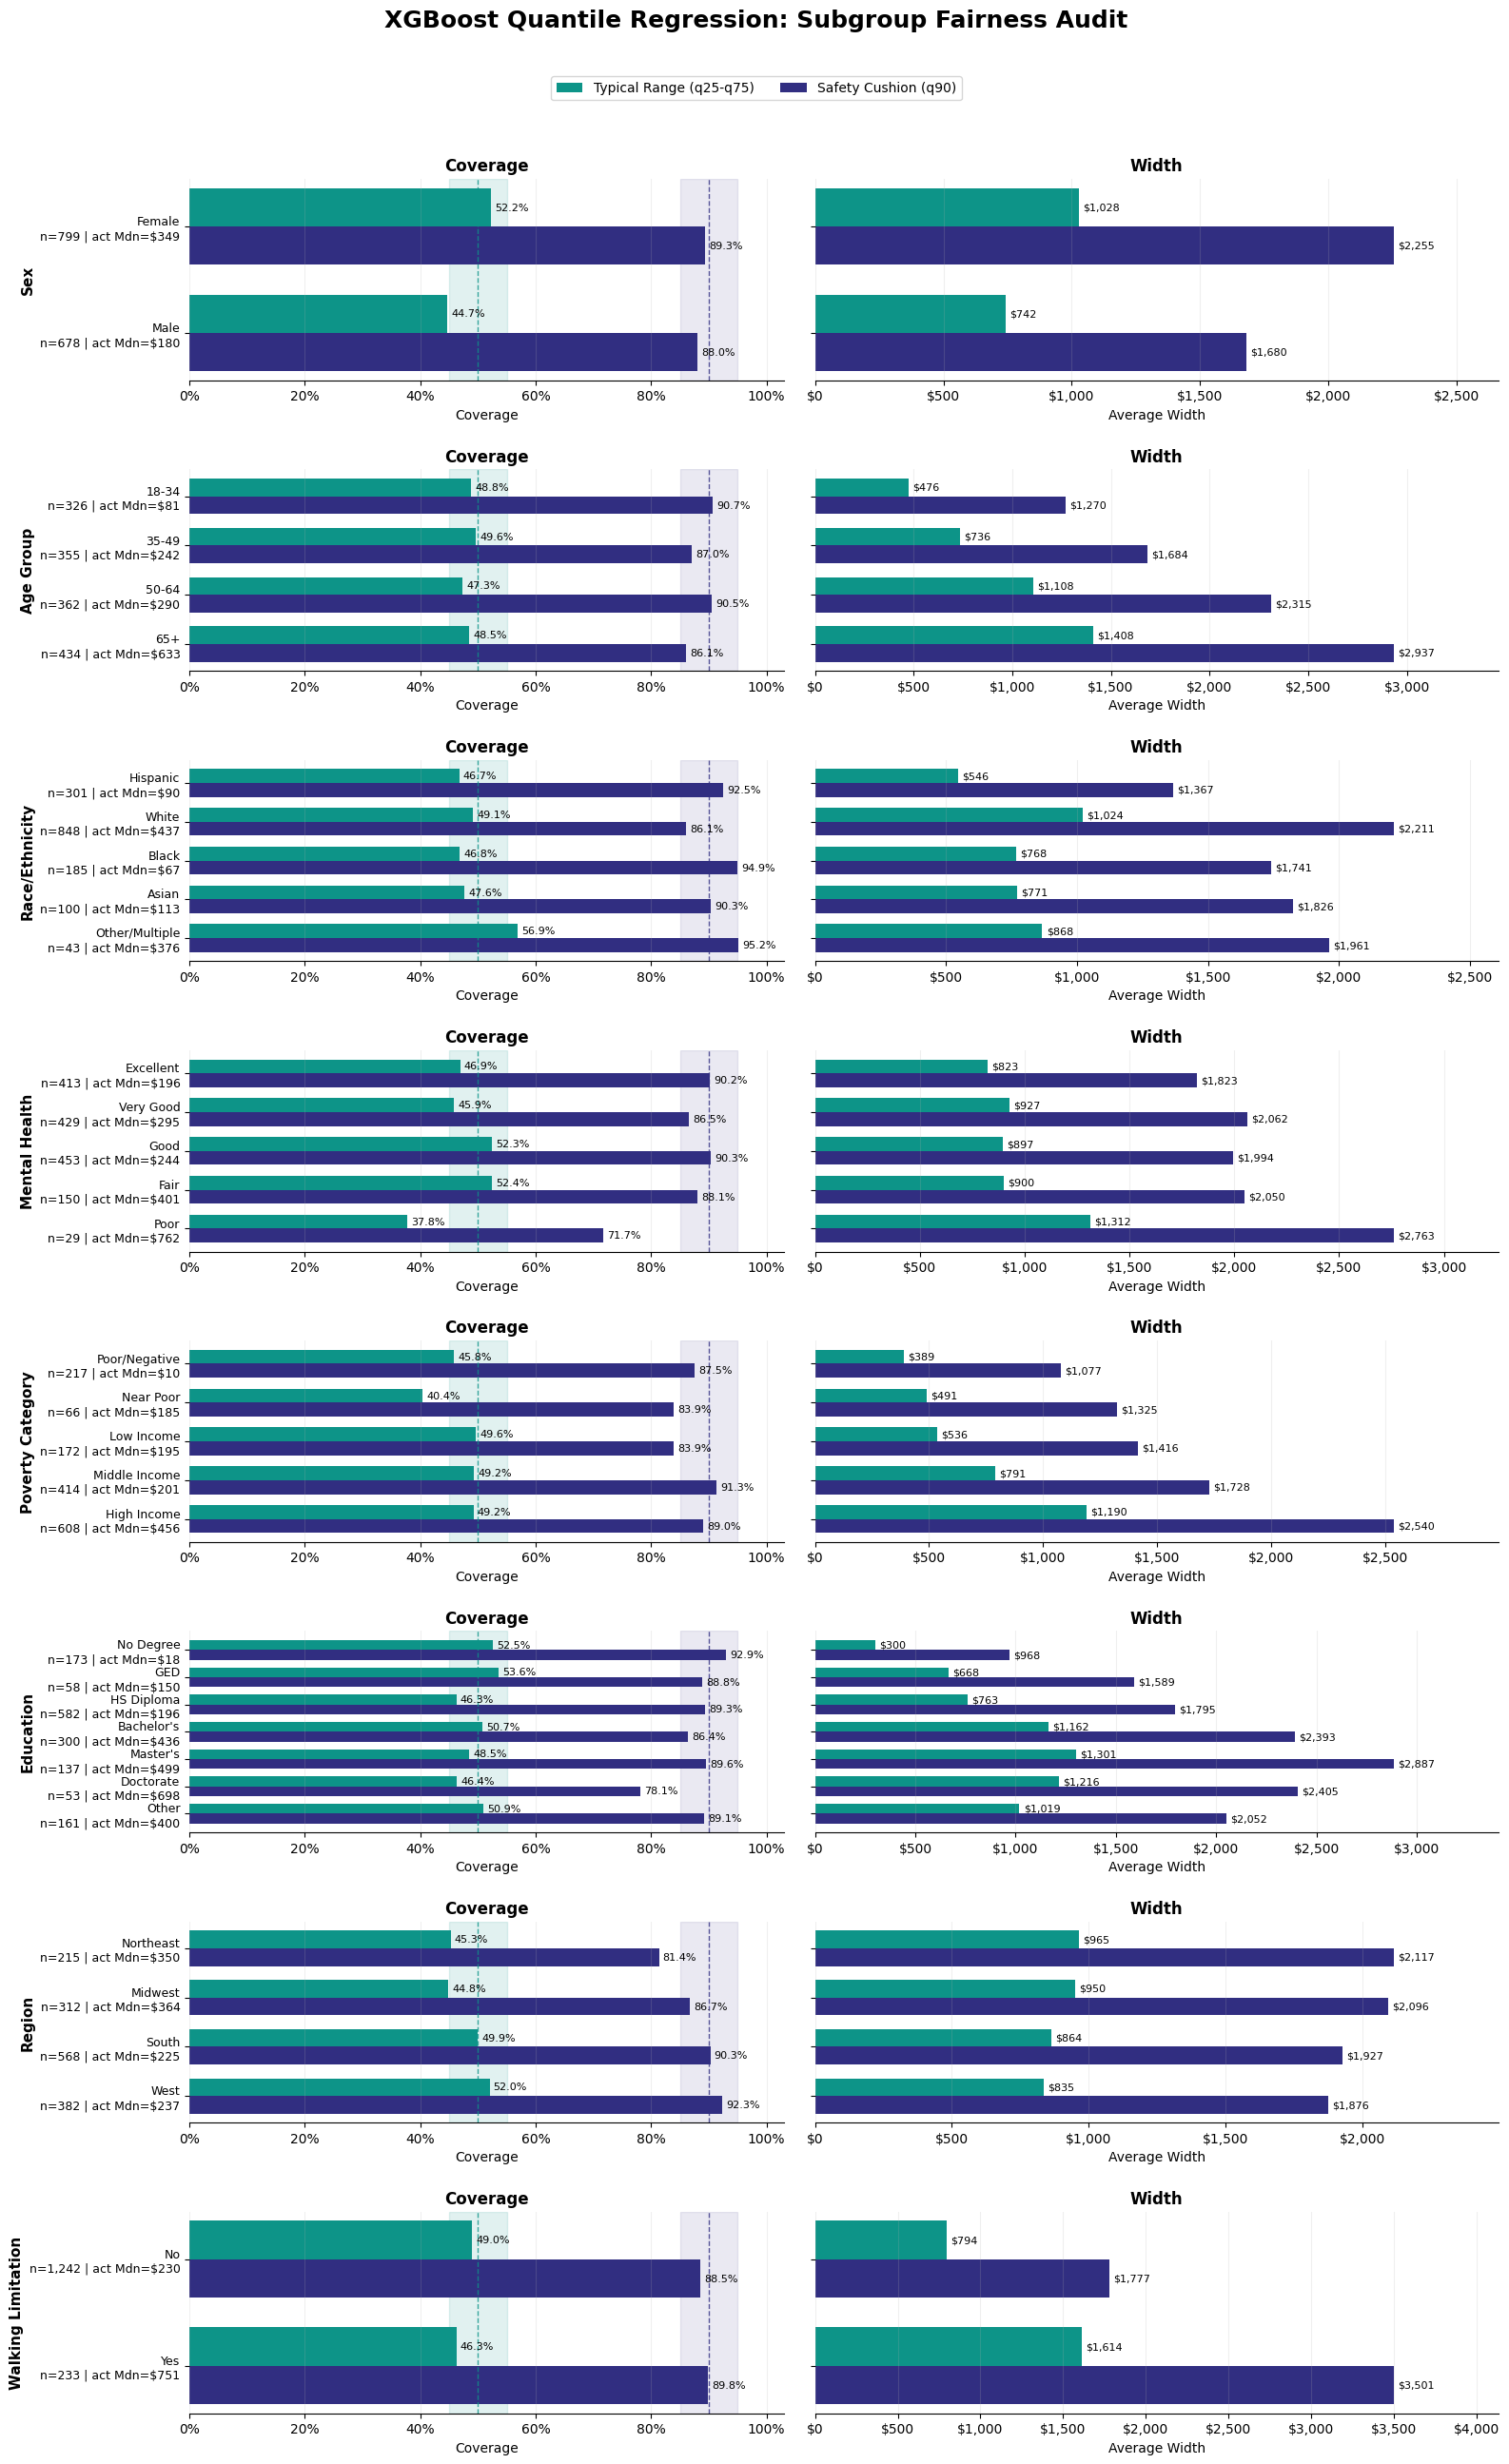

In [45]:
def plot_quantile_subgroup_performance(df, column_labels, title, save_to_file=None):
    """
    Visualizes quantile regression performance across subgroups.

    Each subplot row is one stratification column. The left panel shows coverage for 
    the prediction range (q25-q75) and safety cushion (q90). The right panel shows
    the corresponding range widths in USD.

    Args:
        df (pd.DataFrame): Stratified error analysis dataframe of quantile regression.
        column_labels (list): Ordered list of column labels to include.
        title (str): Main figure title.
        save_to_file (str, optional): Full path and filename to save the plot.
    """
    plot_data = df[df["Column"].isin(column_labels)].copy()
    n_rows = len(column_labels)

    fig, axes = plt.subplots(
        n_rows,
        2,
        figsize=(16, 3.2 * n_rows),
        squeeze=False,  # Guarantees axes is always a 2D array
        gridspec_kw={"width_ratios": [1.0, 1.15]}  # Right panel 15% wider than left panel
    )

    bar_height = 0.36
    colors = {
        "Range": TYPICAL_RANGE_COLOR,
        "Cushion": SAFETY_CUSHION_COLOR,
    }
    percent_fmt = plt.FuncFormatter(lambda x, _: f"{x:.0%}")
    currency_fmt = plt.FuncFormatter(lambda x, _: f"${x:,.0f}")

    for row_idx, column_label in enumerate(column_labels):
        col_data = plot_data[plot_data["Column"] == column_label].copy()
        y_pos = np.arange(len(col_data))

        coverage_ax = axes[row_idx, 0]
        width_ax = axes[row_idx, 1]

        # Coverage (left panel)
        coverage_ax.axvspan(0.45, 0.55, color=TYPICAL_RANGE_COLOR, alpha=0.12, zorder=0)
        coverage_ax.axvspan(0.85, 0.95, color=SAFETY_CUSHION_COLOR, alpha=0.10, zorder=0)
        coverage_ax.axvline(0.50, color=TYPICAL_RANGE_COLOR, linestyle="--", linewidth=1, alpha=0.8)
        coverage_ax.axvline(0.90, color=SAFETY_CUSHION_COLOR, linestyle="--", linewidth=1, alpha=0.8)

        coverage_bars_range = coverage_ax.barh(
            y_pos - bar_height / 2,
            col_data["Prediction Range Coverage"],
            height=bar_height,
            color=colors["Range"],
            label="Typical Range (q25-q75)"
        )
        coverage_bars_cushion = coverage_ax.barh(
            y_pos + bar_height / 2,
            col_data["Safety Cushion Coverage"],
            height=bar_height,
            color=colors["Cushion"],
            label="Safety Cushion (q90)"
        )

        coverage_ax.bar_label(
            coverage_bars_range,
            labels=[f"{v:.1%}" for v in col_data["Prediction Range Coverage"]],
            padding=3,
            fontsize=8
        )
        coverage_ax.bar_label(
            coverage_bars_cushion,
            labels=[f"{v:.1%}" for v in col_data["Safety Cushion Coverage"]],
            padding=3,
            fontsize=8
        )
        coverage_ax.set_xlim(0, 1.03)
        coverage_ax.xaxis.set_major_formatter(percent_fmt)
        coverage_ax.set_title("Coverage", fontsize=12, fontweight="bold")

        # Width (right panel)
        width_bars_range = width_ax.barh(
            y_pos - bar_height / 2,
            col_data["Prediction Range Width"],
            height=bar_height,
            color=colors["Range"],
            label="Typical Range (q25-q75)"
        )
        width_bars_cushion = width_ax.barh(
            y_pos + bar_height / 2,
            col_data["Safety Cushion Width"],
            height=bar_height,
            color=colors["Cushion"],
            label="Safety Cushion (q50-q90)"
        )

        width_ax.bar_label(
            width_bars_range,
            labels=[f"${v:,.0f}" for v in col_data["Prediction Range Width"]],
            padding=3,
            fontsize=8
        )
        width_ax.bar_label(
            width_bars_cushion,
            labels=[f"${v:,.0f}" for v in col_data["Safety Cushion Width"]],
            padding=3,
            fontsize=8
        )
        width_ax.xaxis.set_major_formatter(currency_fmt)
        width_ax.set_title("Width", fontsize=12, fontweight="bold")
        width_ax.margins(x=0.18)

        # Shared row formatting
        coverage_ax.set_yticks(y_pos)
        coverage_ax.set_yticklabels(col_data["Group"], fontsize=9)
        width_ax.set_yticks(y_pos)
        width_ax.set_yticklabels([])
        coverage_ax.invert_yaxis()
        width_ax.invert_yaxis()
        coverage_ax.set_ylabel(column_label, fontsize=11, fontweight="bold")
        width_ax.set_ylabel("")

        for ax in [coverage_ax, width_ax]:
            ax.grid(axis="x", alpha=0.20)
            sns.despine(ax=ax, left=True)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.985), ncol=2, frameon=True)
    fig.suptitle(title, fontsize=18, fontweight="bold", y=1.01)
    plt.tight_layout(rect=[0, 0, 1, 0.97], h_pad=2.0, w_pad=1.4)

    if save_to_file:
        plt.savefig(save_to_file, bbox_inches="tight", dpi=200)

    plt.show()


quantile_reliability_labels = [c["label"] for c in quantile_reliability_configs]
plot_quantile_subgroup_performance(
    quantile_subgroup_df,
    quantile_reliability_labels,
    "XGBoost Quantile Regression: Subgroup Reliability Audit",
    # save_to_file="../figures/evaluation/quantile_subgroup_reliability.png"
)

quantile_fairness_labels = [c["label"] for c in quantile_fairness_configs]
plot_quantile_subgroup_performance(
    quantile_subgroup_df,
    quantile_fairness_labels,
    "XGBoost Quantile Regression: Subgroup Fairness Audit",
    # save_to_file="../figures/evaluation/quantile_subgroup_fairness.png"
)